# 09 — OpenCV Classical Metrics

This notebook computes full-reference classical image-quality metrics for the
OpenCV Telea restoration outputs produced by Notebook 08.

## Metrics

The notebook computes:

- mean squared error (MSE);
- mean absolute error (MAE);
- peak signal-to-noise ratio (PSNR);
- structural similarity index (SSIM), where spatially meaningful.

Each metric compares:

1. the damaged input against the clean reference;
2. the restored output against the clean reference;
3. the improvement obtained by restoration.

For error metrics, positive improvement means reduced error:

- `mse_improvement = damaged_mse - restored_mse`;
- `mae_improvement = damaged_mae - restored_mae`.

For similarity metrics, positive improvement means increased similarity:

- `psnr_improvement = restored_psnr - damaged_psnr`;
- `ssim_improvement = restored_ssim - damaged_ssim`.

## Refined region policy

Metrics are computed across the following evaluation regions:

- `full_image`;
- `content_region`;
- `masked_region`;
- `mask_bbox_crop`;
- `boundary_region`;
- `outside_mask_region`.

MSE, MAE, and PSNR are valid for all non-empty regions.

SSIM requires contiguous spatial image structure and is therefore computed only
for image-like rectangular regions:

- `full_image`;
- `content_region`;
- `mask_bbox_crop`.

SSIM is not computed for sparse or irregular pixel selections:

- `masked_region`;
- `boundary_region`;
- `outside_mask_region`.

## Zero-control policy

Zero-control cases contain no inpainting target.

They contribute:

- `full_image`;
- `content_region`;
- `outside_mask_region`.

They do not contribute:

- `masked_region`;
- `mask_bbox_crop`;
- `boundary_region`.

## Dataset policy

The unified Notebook 08 restoration metadata may contain:

- `canonical`;
- `damage_size`;
- `mask_robustness`;
- `synthetic_degradation`.

Canonical and damage-size cases are required.

Mask-robustness and synthetic-degradation cases are included when present.

Synthetic-degradation masks represent grayscale effect intensity rather than
ordinary missing-content masks. To remain consistent with Notebook 08 and the
frozen OpenCV Telea restoration policy, the metric target is defined using:

```text
mask intensity > 127
```

Synthetic-degradation results are retained as supplementary method-behavior
diagnostics and must not be pooled uncritically with primary missing-content
experiments.

## Canonical outputs

```powershell
data/processed/metrics/
    metrics_opencv_telea_classical.csv

outputs/
├── 09_opencv_metrics_classical/
│   └── opencv_metrics_classical_audit.csv
├── figures/
│   └── opencv_metrics_classical/
└── reports/
    ├── opencv_metrics_classical_manifest.json
    └── opencv_metrics_classical_report.md
```

In [1]:
from pathlib import Path


def find_project_root(
    start_path: Path,
) -> Path:
    """Find the repository root from a notebook or working directory."""
    start_path = start_path.resolve()

    candidate_paths = [
        start_path,
        *start_path.parents,
    ]

    root_markers = (
        ".git",
        "src",
        "data",
        "outputs",
    )

    for candidate_path in candidate_paths:
        marker_count = sum(
            (
                candidate_path
                / marker_name
            ).exists()
            for marker_name
            in root_markers
        )

        if marker_count >= 3:
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root from "
        f"{start_path}."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

print(
    "Project root:",
    PROJECT_ROOT,
)

Project root: D:\Masters\FH\Thesis\painting-restoration-eval


In [2]:
from __future__ import annotations

import json
import math
import platform
import shutil
import sys
from datetime import datetime, timezone
from hashlib import sha256
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import skimage
from PIL import Image


SRC_DIR = (
    PROJECT_ROOT
    / "src"
)

if str(
    SRC_DIR
) not in sys.path:
    sys.path.insert(
        0,
        str(
            SRC_DIR
        ),
    )


from restoration_eval import metrics_classical
from restoration_eval.metrics_classical import (
    CLASSICAL_METRIC_COLUMNS,
    compute_image_region_metrics,
    compute_mae,
    compute_mse,
    compute_psnr_from_mse,
    compute_ssim_safe,
    summarize_classical_metrics,
)


required_metric_module_exports = (
    "CLASSICAL_METRIC_COLUMNS",
    "compute_mse",
    "compute_mae",
    "compute_psnr_from_mse",
    "compute_ssim_safe",
    "compute_image_region_metrics",
    "summarize_classical_metrics",
)


missing_metric_module_exports = [
    export_name
    for export_name
    in required_metric_module_exports
    if not hasattr(
        metrics_classical,
        export_name,
    )
]


if missing_metric_module_exports:
    raise ImportError(
        "The classical metric module is missing "
        "required exports: "
        f"{missing_metric_module_exports}"
    )


runtime_environment_df = pd.DataFrame(
    [
        {
            "component": "python",
            "version": (
                platform.python_version()
            ),
        },
        {
            "component": "platform",
            "version": (
                platform.platform()
            ),
        },
        {
            "component": "numpy",
            "version": np.__version__,
        },
        {
            "component": "pandas",
            "version": pd.__version__,
        },
        {
            "component": "Pillow",
            "version": PIL.__version__,
        },
        {
            "component": "matplotlib",
            "version": (
                matplotlib.__version__
            ),
        },
        {
            "component": "scikit-image",
            "version": (
                skimage.__version__
            ),
        },
        {
            "component": (
                "metrics_module"
            ),
            "version": getattr(
                metrics_classical,
                "CLASSICAL_METRIC_VERSION",
                "legacy-unversioned",
            ),
        },
    ]
)


display(
    runtime_environment_df
)

,component,version
0,python,3.12.6
1,platform,Windows-11-10.0.26200-SP0
2,numpy,1.26.4
3,pandas,2.3.3
4,Pillow,9.5.0
5,matplotlib,3.11.0
6,scikit-image,0.24.0
7,metrics_module,legacy-unversioned


In [3]:
# Canonical metric configuration

NOTEBOOK_NAME = (
    "09_opencv_metrics_classical"
)

MODEL_NAME = (
    "opencv_telea"
)

TARGET_SIZE = 768

MASK_BINARY_THRESHOLD = 127

MASK_BBOX_MARGIN = 8

BOUNDARY_WIDTH_PIXELS = 5

PROGRESS_EVERY = 25

METRIC_SCHEMA_VERSION = "2.0.0"

METRIC_IMPLEMENTATION_NAME = (
    "restoration_eval.metrics_classical"
)


REQUIRED_DATASETS = (
    "canonical",
    "damage_size",
)

OPTIONAL_DATASETS = (
    "mask_robustness",
    "synthetic_degradation",
)

SUPPORTED_DATASETS = (
    *REQUIRED_DATASETS,
    *OPTIONAL_DATASETS,
)


SSIM_SUPPORTED_REGIONS = (
    "full_image",
    "content_region",
    "mask_bbox_crop",
)

PIXEL_ONLY_REGIONS = (
    "masked_region",
    "boundary_region",
    "outside_mask_region",
)

NONZERO_MASK_REGIONS = (
    "masked_region",
    "mask_bbox_crop",
    "boundary_region",
)

ALL_EVALUATION_REGIONS = (
    "full_image",
    "content_region",
    "masked_region",
    "mask_bbox_crop",
    "boundary_region",
    "outside_mask_region",
)


DATA_DIR = (
    PROJECT_ROOT
    / "data"
)

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

METADATA_DIR = (
    PROCESSED_DIR
    / "metadata"
)

PROCESSED_METRICS_DIR = (
    PROCESSED_DIR
    / "metrics"
)


RESTORATION_METADATA_PATH = (
    METADATA_DIR
    / "metadata_restored_opencv_telea.csv"
)

CLEAN_METADATA_PATH = (
    METADATA_DIR
    / "metadata_processed_clean.csv"
)


OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
)

NOTEBOOK_OUTPUT_DIR = (
    OUTPUTS_DIR
    / "09_opencv_metrics_classical"
)

FIGURE_DIR = (
    OUTPUTS_DIR
    / "figures"
    / "opencv_metrics_classical"
)

REPORT_DIR = (
    OUTPUTS_DIR
    / "reports"
)


METRICS_OUTPUT_PATH = (
    PROCESSED_METRICS_DIR
    / "metrics_opencv_telea_classical.csv"
)

AUDIT_OUTPUT_PATH = (
    NOTEBOOK_OUTPUT_DIR
    / "opencv_metrics_classical_audit.csv"
)

MANIFEST_OUTPUT_PATH = (
    REPORT_DIR
    / "opencv_metrics_classical_manifest.json"
)

REPORT_OUTPUT_PATH = (
    REPORT_DIR
    / "opencv_metrics_classical_report.md"
)


TEMPORARY_OUTPUT_DIR = (
    NOTEBOOK_OUTPUT_DIR
    / "_temporary"
)

SMOKE_TEST_OUTPUT_DIR = (
    TEMPORARY_OUTPUT_DIR
    / "smoke_test"
)


for output_directory in (
    PROCESSED_METRICS_DIR,
    NOTEBOOK_OUTPUT_DIR,
    FIGURE_DIR,
    REPORT_DIR,
):
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


configuration_df = pd.DataFrame(
    [
        {
            "parameter": (
                "target_size"
            ),
            "value": TARGET_SIZE,
        },
        {
            "parameter": (
                "mask_binary_threshold"
            ),
            "value": (
                f"> {MASK_BINARY_THRESHOLD}"
            ),
        },
        {
            "parameter": (
                "mask_bbox_margin"
            ),
            "value": (
                MASK_BBOX_MARGIN
            ),
        },
        {
            "parameter": (
                "boundary_width_pixels"
            ),
            "value": (
                BOUNDARY_WIDTH_PIXELS
            ),
        },
        {
            "parameter": (
                "metric_schema_version"
            ),
            "value": (
                METRIC_SCHEMA_VERSION
            ),
        },
        {
            "parameter": (
                "required_datasets"
            ),
            "value": list(
                REQUIRED_DATASETS
            ),
        },
        {
            "parameter": (
                "optional_datasets"
            ),
            "value": list(
                OPTIONAL_DATASETS
            ),
        },
    ]
)


display(
    configuration_df
)

,parameter,value
0,target_size,768
1,mask_binary_threshold,> 127
2,mask_bbox_margin,8
3,boundary_width_pixels,5
4,metric_schema_version,2.0.0
5,required_datasets,"[canonical, damage_size]"
6,optional_datasets,"[mask_robustness, synthetic_degradation]"


In [4]:
def resolve_project_path(
    path_value: Any,
) -> Path:
    """Resolve a project-relative or absolute path."""
    if path_value is None:
        raise ValueError(
            "Path value is None."
        )

    try:
        if pd.isna(
            path_value
        ):
            raise ValueError(
                "Path value is null."
            )
    except TypeError:
        pass

    path_text = str(
        path_value
    ).strip()

    if not path_text:
        raise ValueError(
            "Path value is blank."
        )

    path = Path(
        path_text
    )

    if path.is_absolute():
        return path.resolve()

    return (
        PROJECT_ROOT
        / path
    ).resolve()


def project_relative_path(
    path_value: Any,
) -> str:
    """Return a portable project-relative path where possible."""
    path = resolve_project_path(
        path_value
    )

    try:
        return path.relative_to(
            PROJECT_ROOT.resolve()
        ).as_posix()
    except ValueError:
        return path.as_posix()


def file_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """Calculate a SHA-256 checksum."""
    digest = sha256()

    with Path(
        file_path
    ).open(
        "rb"
    ) as file_handle:
        while True:
            chunk = file_handle.read(
                chunk_size
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    return digest.hexdigest()


def first_existing_column(
    dataframe: pd.DataFrame,
    candidates: tuple[str, ...],
    semantic_name: str,
    required: bool = True,
) -> str | None:
    """Return the first supported column present in a DataFrame."""
    for column_name in candidates:
        if column_name in dataframe.columns:
            return column_name

    if required:
        raise ValueError(
            f"Metadata does not contain a supported "
            f"{semantic_name} column. Expected one of: "
            f"{list(candidates)}"
        )

    return None

In [5]:
# Load the unified Notebook 08 restoration metadata

if not RESTORATION_METADATA_PATH.is_file():
    raise FileNotFoundError(
        "Notebook 08 restoration metadata was not found: "
        f"{RESTORATION_METADATA_PATH}"
    )


restoration_metadata_df = pd.read_csv(
    RESTORATION_METADATA_PATH
)


required_restoration_columns = {
    "restoration_case_id",
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "clean_path",
    "damaged_path",
    "mask_path",
    "restored_path",
    "status",
    "issue",
}


missing_restoration_columns = sorted(
    required_restoration_columns
    - set(
        restoration_metadata_df.columns
    )
)


if missing_restoration_columns:
    raise ValueError(
        "Notebook 08 restoration metadata is "
        "missing required columns: "
        f"{missing_restoration_columns}"
    )


restoration_metadata_df[
    "dataset_name"
] = (
    restoration_metadata_df[
        "dataset_name"
    ]
    .astype(str)
    .str.strip()
)


restoration_metadata_df[
    "restoration_case_id"
] = (
    restoration_metadata_df[
        "restoration_case_id"
    ]
    .astype(str)
    .str.strip()
)


restoration_metadata_df[
    "case_id"
] = (
    restoration_metadata_df[
        "case_id"
    ]
    .astype(str)
    .str.strip()
)


restoration_metadata_df[
    "painting_id"
] = (
    restoration_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .str.strip()
)


restoration_status_error_df = (
    restoration_metadata_df.loc[
        restoration_metadata_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .copy()
)


duplicate_restoration_ids = (
    restoration_metadata_df[
        "restoration_case_id"
    ]
    .duplicated(
        keep=False
    )
)


included_dataset_names = sorted(
    restoration_metadata_df[
        "dataset_name"
    ]
    .unique()
    .tolist()
)


unsupported_dataset_names = sorted(
    set(
        included_dataset_names
    )
    - set(
        SUPPORTED_DATASETS
    )
)


missing_required_dataset_names = sorted(
    set(
        REQUIRED_DATASETS
    )
    - set(
        included_dataset_names
    )
)


restoration_metadata_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "restoration_metadata_nonempty"
            ),
            "observed": len(
                restoration_metadata_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    restoration_metadata_df
                )
                > 0
            ),
        },
        {
            "check": (
                "restoration_case_ids_unique"
            ),
            "observed": int(
                duplicate_restoration_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_restoration_ids.any()
            ),
        },
        {
            "check": (
                "all_restoration_statuses_ok"
            ),
            "observed": len(
                restoration_status_error_df
            ),
            "expected": 0,
            "passed": (
                restoration_status_error_df.empty
            ),
        },
        {
            "check": (
                "required_datasets_present"
            ),
            "observed": (
                included_dataset_names
            ),
            "expected": list(
                REQUIRED_DATASETS
            ),
            "passed": (
                len(
                    missing_required_dataset_names
                )
                == 0
            ),
        },
        {
            "check": (
                "no_unsupported_datasets"
            ),
            "observed": (
                unsupported_dataset_names
            ),
            "expected": [],
            "passed": (
                len(
                    unsupported_dataset_names
                )
                == 0
            ),
        },
        {
            "check": (
                "model_name_consistent"
            ),
            "observed": sorted(
                restoration_metadata_df[
                    "model_name"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "expected": [
                MODEL_NAME
            ],
            "passed": (
                set(
                    restoration_metadata_df[
                        "model_name"
                    ]
                    .astype(str)
                )
                == {
                    MODEL_NAME
                }
            ),
        },
    ]
)


restoration_dataset_summary_df = (
    restoration_metadata_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        restoration_cases=(
            "restoration_case_id",
            "count",
        ),
        unique_restoration_cases=(
            "restoration_case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        successful_cases=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("ok")
                .sum()
            ),
        ),
    )
    .reset_index()
)


display(
    restoration_dataset_summary_df
)

display(
    restoration_metadata_checks_df
)


if not (
    restoration_metadata_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Notebook 08 restoration metadata gate failed."
    )

,dataset_name,restoration_cases,unique_restoration_cases,paintings,successful_cases
0,canonical,250,250,50,250
1,damage_size,35,35,5,35
2,mask_robustness,75,75,5,75
3,synthetic_degradation,50,50,5,50


,check,observed,expected,passed
0,restoration_metadata_nonempty,410,> 0,True
1,restoration_case_ids_unique,0,0,True
2,all_restoration_statuses_ok,0,0,True
3,required_datasets_present,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size]",True
4,no_unsupported_datasets,[],[],True
5,model_name_consistent,[opencv_telea],[opencv_telea],True


In [6]:
# Load canonical preprocessing metadata for content-region coordinates

if not CLEAN_METADATA_PATH.is_file():
    raise FileNotFoundError(
        "Clean preprocessing metadata was not found: "
        f"{CLEAN_METADATA_PATH}"
    )


clean_metadata_df = pd.read_csv(
    CLEAN_METADATA_PATH
)


required_clean_columns = {
    "painting_id",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
}


missing_clean_columns = sorted(
    required_clean_columns
    - set(
        clean_metadata_df.columns
    )
)


if missing_clean_columns:
    raise ValueError(
        "Clean preprocessing metadata is missing "
        "required columns: "
        f"{missing_clean_columns}"
    )


clean_metadata_df[
    "painting_id"
] = (
    clean_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .str.strip()
)


duplicate_clean_painting_ids = (
    clean_metadata_df[
        "painting_id"
    ]
    .duplicated(
        keep=False
    )
)


for coordinate_column in (
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
):
    clean_metadata_df[
        coordinate_column
    ] = pd.to_numeric(
        clean_metadata_df[
            coordinate_column
        ],
        errors="coerce",
    )


invalid_content_coordinates = (
    clean_metadata_df[
        [
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
        ]
    ]
    .isna()
    .any(
        axis=1
    )
    |
    ~(
        clean_metadata_df[
            "content_x_min"
        ]
        .ge(0)
        &
        clean_metadata_df[
            "content_y_min"
        ]
        .ge(0)
        &
        clean_metadata_df[
            "content_x_max"
        ]
        .le(TARGET_SIZE)
        &
        clean_metadata_df[
            "content_y_max"
        ]
        .le(TARGET_SIZE)
        &
        clean_metadata_df[
            "content_x_max"
        ]
        .gt(
            clean_metadata_df[
                "content_x_min"
            ]
        )
        &
        clean_metadata_df[
            "content_y_max"
        ]
        .gt(
            clean_metadata_df[
                "content_y_min"
            ]
        )
    )
)


clean_metadata_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "clean_metadata_nonempty"
            ),
            "observed": len(
                clean_metadata_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    clean_metadata_df
                )
                > 0
            ),
        },
        {
            "check": (
                "painting_ids_unique"
            ),
            "observed": int(
                duplicate_clean_painting_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_clean_painting_ids.any()
            ),
        },
        {
            "check": (
                "content_coordinates_valid"
            ),
            "observed": int(
                invalid_content_coordinates.sum()
            ),
            "expected": 0,
            "passed": (
                not invalid_content_coordinates.any()
            ),
        },
    ]
)


display(
    clean_metadata_df.head()
)

display(
    clean_metadata_checks_df
)


if not (
    clean_metadata_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Clean preprocessing metadata gate failed."
    )

,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,content_y_max,content_width,content_height,preprocessing_method,orientation,content_area_pixels,canvas_area_pixels,content_area_percentage,padding_area_pixels,padding_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,663,768,aspect_ratio_resize_median_rgb_pad,portrait,509184,589824,86.3281,80640,13.6719
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,449,768,aspect_ratio_resize_median_rgb_pad,portrait,344832,589824,58.4635,244992,41.5365
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,614,768,aspect_ratio_resize_median_rgb_pad,portrait,471552,589824,79.9479,118272,20.0521
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,696,768,625,aspect_ratio_resize_median_rgb_pad,landscape,480000,589824,81.3802,109824,18.6198
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,768,569,768,aspect_ratio_resize_median_rgb_pad,portrait,436992,589824,74.0885,152832,25.9115


,check,observed,expected,passed
0,clean_metadata_nonempty,50,> 0,True
1,painting_ids_unique,0,0,True
2,content_coordinates_valid,0,0,True


In [10]:
# Enrich Notebook 08 restoration metadata with clean-image metadata

clean_enrichment_columns = [
    column_name
    for column_name in (
        "painting_id",
        "category",
        "title",
        "artist",
        "style",
        "source",
        "content_x_min",
        "content_y_min",
        "content_x_max",
        "content_y_max",
        "content_width",
        "content_height",
        "target_size",
    )
    if column_name
    in clean_metadata_df.columns
]


metric_input_df = (
    restoration_metadata_df
    .merge(
        clean_metadata_df[
            clean_enrichment_columns
        ],
        on="painting_id",
        how="left",
        validate="many_to_one",
        suffixes=(
            "",
            "_clean_metadata",
        ),
        indicator=True,
    )
)


unmatched_painting_rows_df = (
    metric_input_df.loc[
        metric_input_df[
            "_merge"
        ]
        .astype(str)
        .ne("both")
    ]
    .copy()
)


metric_input_df = (
    metric_input_df
    .drop(
        columns=[
            "_merge"
        ]
    )
)


# Prefer authoritative preprocessing metadata when merge suffixes exist.

content_metadata_columns = (
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
    "target_size",
)


for column_name in content_metadata_columns:
    clean_column_name = (
        f"{column_name}_clean_metadata"
    )

    if clean_column_name in metric_input_df.columns:
        if column_name in metric_input_df.columns:
            metric_input_df[
                column_name
            ] = (
                metric_input_df[
                    clean_column_name
                ]
                .combine_first(
                    metric_input_df[
                        column_name
                    ]
                )
            )
        else:
            metric_input_df[
                column_name
            ] = metric_input_df[
                clean_column_name
            ]

        metric_input_df = (
            metric_input_df.drop(
                columns=[
                    clean_column_name
                ]
            )
        )


# Preserve or derive a stable source-case identifier.

if (
    "source_case_id_original"
    not in metric_input_df.columns
):
    metric_input_df[
        "source_case_id_original"
    ] = metric_input_df.get(
        "source_case_id",
        metric_input_df[
            "case_id"
        ],
    )


if (
    "source_case_id"
    not in metric_input_df.columns
):
    metric_input_df[
        "source_case_id"
    ] = metric_input_df[
        "case_id"
    ]


# Normalize mask ID and mask type without discarding upstream metadata.

mask_id_source_column = (
    first_existing_column(
        metric_input_df,
        candidates=(
            "mask_id",
            "sensitivity_mask_id",
            "robustness_mask_id",
            "synthetic_effect_mask_id",
            "effect_mask_id",
            "case_id",
        ),
        semantic_name="mask identifier",
    )
)


mask_type_source_column = (
    first_existing_column(
        metric_input_df,
        candidates=(
            "mask_type",
            "damage_type",
            "damage_level",
            "sensitivity_level",
            "robustness_variant",
            "degradation_type",
            "synthetic_degradation_type",
            "case_id",
        ),
        semantic_name="mask or degradation type",
    )
)


metric_input_df[
    "metric_mask_id"
] = (
    metric_input_df[
        mask_id_source_column
    ]
    .astype(str)
    .str.strip()
)


metric_input_df[
    "metric_mask_type"
] = (
    metric_input_df[
        mask_type_source_column
    ]
    .astype(str)
    .str.strip()
)


# Retain compatibility aliases for later metric code.

if (
    "mask_id"
    not in metric_input_df.columns
):
    metric_input_df[
        "mask_id"
    ] = metric_input_df[
        "metric_mask_id"
    ]


if (
    "mask_type"
    not in metric_input_df.columns
):
    metric_input_df[
        "mask_type"
    ] = metric_input_df[
        "metric_mask_type"
    ]


metric_input_df[
    "metric_case_id"
] = (
    metric_input_df[
        "restoration_case_id"
    ]
    .astype(str)
)


metric_input_df[
    "metric_schema_version"
] = METRIC_SCHEMA_VERSION


metric_input_df[
    "metric_implementation_name"
] = (
    METRIC_IMPLEMENTATION_NAME
)


metric_input_df[
    "mask_threshold_rule"
] = (
    f"intensity > "
    f"{MASK_BINARY_THRESHOLD}"
)


metric_input_df[
    "metric_applicability"
] = np.where(
    metric_input_df[
        "dataset_name"
    ]
    .astype(str)
    .eq(
        "synthetic_degradation"
    ),
    "supplementary",
    "primary",
)


duplicate_metric_case_ids = (
    metric_input_df[
        "metric_case_id"
    ]
    .duplicated(
        keep=False
    )
)


null_content_metadata_rows = (
    metric_input_df[
        [
            "content_x_min",
            "content_y_min",
            "content_x_max",
            "content_y_max",
        ]
    ]
    .isna()
    .any(
        axis=1
    )
)


metric_input_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "metric_input_row_count"
            ),
            "observed": len(
                metric_input_df
            ),
            "expected": len(
                restoration_metadata_df
            ),
            "passed": (
                len(
                    metric_input_df
                )
                == len(
                    restoration_metadata_df
                )
            ),
        },
        {
            "check": (
                "all_paintings_matched"
            ),
            "observed": len(
                unmatched_painting_rows_df
            ),
            "expected": 0,
            "passed": (
                unmatched_painting_rows_df.empty
            ),
        },
        {
            "check": (
                "metric_case_ids_unique"
            ),
            "observed": int(
                duplicate_metric_case_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_metric_case_ids.any()
            ),
        },
        {
            "check": (
                "content_metadata_complete"
            ),
            "observed": int(
                null_content_metadata_rows.sum()
            ),
            "expected": 0,
            "passed": (
                not null_content_metadata_rows.any()
            ),
        },
        {
            "check": (
                "dataset_names_preserved"
            ),
            "observed": sorted(
                metric_input_df[
                    "dataset_name"
                ]
                .astype(str)
                .unique()
                .tolist()
            ),
            "expected": (
                included_dataset_names
            ),
            "passed": (
                set(
                    metric_input_df[
                        "dataset_name"
                    ]
                    .astype(str)
                )
                == set(
                    included_dataset_names
                )
            ),
        },
    ]
)


metric_input_summary_df = (
    metric_input_df
    .groupby(
        [
            "dataset_name",
            "metric_applicability",
        ],
        dropna=False,
        sort=False,
    )
    .agg(
        cases=(
            "metric_case_id",
            "count",
        ),
        unique_cases=(
            "metric_case_id",
            "nunique",
        ),
        paintings=(
            "painting_id",
            "nunique",
        ),
        mask_types=(
            "metric_mask_type",
            "nunique",
        ),
    )
    .reset_index()
)


display(
    metric_input_summary_df
)

display(
    metric_input_checks_df
)


if not (
    metric_input_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Unified classical-metric input manifest "
        "validation failed."
    )

E:\HFCache\tmp\ipykernel_27412\1059100253.py:91: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(
E:\HFCache\tmp\ipykernel_27412\1059100253.py:91: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(
E:\HFCache\tmp\ipykernel_27412\1059100253.py:91: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  .combine_first(
E:\HFCa

,dataset_name,metric_applicability,cases,unique_cases,paintings,mask_types
0,canonical,primary,250,250,50,5
1,damage_size,primary,35,35,5,1
2,mask_robustness,primary,75,75,5,1
3,synthetic_degradation,supplementary,50,50,5,1


,check,observed,expected,passed
0,metric_input_row_count,410,410,True
1,all_paintings_matched,0,0,True
2,metric_case_ids_unique,0,0,True
3,content_metadata_complete,0,0,True
4,dataset_names_preserved,"[canonical, damage_size, mask_robustness, synt...","[canonical, damage_size, mask_robustness, synt...",True


In [11]:
# Validate metric-input image paths and derive binary-mask properties

def load_metric_mask_array(
    mask_path_value: Any,
) -> np.ndarray:
    """Load a mask using the canonical Notebook 08 threshold."""
    mask_path = resolve_project_path(
        mask_path_value
    )

    with Image.open(
        mask_path
    ) as mask_image:
        mask_array = np.asarray(
            mask_image.convert(
                "L"
            )
        )

    if mask_array.shape != (
        TARGET_SIZE,
        TARGET_SIZE,
    ):
        raise ValueError(
            "Unexpected mask dimensions for "
            f"{mask_path}: {mask_array.shape}"
        )

    return (
        mask_array
        > MASK_BINARY_THRESHOLD
    )


path_validation_rows = []


for row in metric_input_df.itertuples(
    index=False
):
    path_record = {
        "metric_case_id": (
            row.metric_case_id
        ),
        "dataset_name": (
            row.dataset_name
        ),
        "painting_id": (
            row.painting_id
        ),
    }

    all_paths_valid = True
    issues = []

    for path_column in (
        "clean_path",
        "damaged_path",
        "mask_path",
        "restored_path",
    ):
        try:
            resolved_path = (
                resolve_project_path(
                    getattr(
                        row,
                        path_column,
                    )
                )
            )

            exists = (
                resolved_path.is_file()
            )

            if not exists:
                all_paths_valid = False

                issues.append(
                    f"{path_column} missing: "
                    f"{resolved_path}"
                )

            path_record[
                f"{path_column}_exists"
            ] = exists

        except Exception as exc:
            all_paths_valid = False

            path_record[
                f"{path_column}_exists"
            ] = False

            issues.append(
                f"{path_column}: "
                f"{type(exc).__name__}: {exc}"
            )

    mask_area_pixels = np.nan

    if path_record[
        "mask_path_exists"
    ]:
        try:
            mask_bool = (
                load_metric_mask_array(
                    row.mask_path
                )
            )

            mask_area_pixels = int(
                mask_bool.sum()
            )

        except Exception as exc:
            all_paths_valid = False

            issues.append(
                "mask validation: "
                f"{type(exc).__name__}: {exc}"
            )

    path_record[
        "mask_area_pixels"
    ] = mask_area_pixels

    path_record[
        "is_zero_control"
    ] = bool(
        mask_area_pixels == 0
    ) if pd.notna(
        mask_area_pixels
    ) else False

    path_record[
        "path_validation_passed"
    ] = all_paths_valid

    path_record[
        "issue"
    ] = " | ".join(
        issues
    )

    path_validation_rows.append(
        path_record
    )


metric_input_path_validation_df = (
    pd.DataFrame(
        path_validation_rows
    )
)


metric_input_df = (
    metric_input_df
    .merge(
        metric_input_path_validation_df[
            [
                "metric_case_id",
                "mask_area_pixels",
                "is_zero_control",
                "path_validation_passed",
            ]
        ],
        on="metric_case_id",
        how="left",
        validate="one_to_one",
    )
)


failed_path_validation_df = (
    metric_input_path_validation_df.loc[
        ~metric_input_path_validation_df[
            "path_validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


path_validation_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "path_validation_row_count"
            ),
            "observed": len(
                metric_input_path_validation_df
            ),
            "expected": len(
                metric_input_df
            ),
            "passed": (
                len(
                    metric_input_path_validation_df
                )
                == len(
                    metric_input_df
                )
            ),
        },
        {
            "check": (
                "all_required_files_exist"
            ),
            "observed": len(
                failed_path_validation_df
            ),
            "expected": 0,
            "passed": (
                failed_path_validation_df.empty
            ),
        },
        {
            "check": (
                "mask_areas_available"
            ),
            "observed": int(
                metric_input_df[
                    "mask_area_pixels"
                ]
                .notna()
                .sum()
            ),
            "expected": len(
                metric_input_df
            ),
            "passed": bool(
                metric_input_df[
                    "mask_area_pixels"
                ]
                .notna()
                .all()
            ),
        },
    ]
)


mask_property_summary_df = (
    metric_input_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        cases=(
            "metric_case_id",
            "count",
        ),
        zero_control_cases=(
            "is_zero_control",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
        nonzero_mask_cases=(
            "is_zero_control",
            lambda values: int(
                (
                    ~values.astype(bool)
                ).sum()
            ),
        ),
        minimum_mask_area_pixels=(
            "mask_area_pixels",
            "min",
        ),
        median_mask_area_pixels=(
            "mask_area_pixels",
            "median",
        ),
        maximum_mask_area_pixels=(
            "mask_area_pixels",
            "max",
        ),
    )
    .reset_index()
)


display(
    mask_property_summary_df
)

display(
    path_validation_checks_df
)


if not failed_path_validation_df.empty:
    display(
        failed_path_validation_df
    )


if not (
    path_validation_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric-input path validation failed."
    )

,dataset_name,cases,zero_control_cases,nonzero_mask_cases,minimum_mask_area_pixels,median_mask_area_pixels,maximum_mask_area_pixels
0,canonical,250,50,200,0,18344.5,83018
1,damage_size,35,0,35,7777,34593.0,101967
2,mask_robustness,75,0,75,7698,19494.0,63746
3,synthetic_degradation,50,5,45,0,13484.5,315211


,check,observed,expected,passed
0,path_validation_row_count,410,410,True
1,all_required_files_exist,0,0,True
2,mask_areas_available,410,410,True


In [12]:
# Build the expected metric-region manifest dynamically

expected_metric_region_rows = []


for row in metric_input_df.itertuples(
    index=False
):
    base_record = {
        "metric_case_id": (
            row.metric_case_id
        ),
        "restoration_case_id": (
            row.restoration_case_id
        ),
        "dataset_name": (
            row.dataset_name
        ),
        "painting_id": (
            row.painting_id
        ),
        "model_name": (
            row.model_name
        ),
        "is_zero_control": bool(
            row.is_zero_control
        ),
        "metric_applicability": (
            row.metric_applicability
        ),
    }

    case_regions = [
        "full_image",
        "content_region",
        "outside_mask_region",
    ]

    if not bool(
        row.is_zero_control
    ):
        case_regions.extend(
            [
                "masked_region",
                "mask_bbox_crop",
                "boundary_region",
            ]
        )

    for evaluation_region in (
        case_regions
    ):
        expected_metric_region_rows.append(
            {
                **base_record,
                "evaluation_region": (
                    evaluation_region
                ),
                "ssim_expected": (
                    evaluation_region
                    in SSIM_SUPPORTED_REGIONS
                ),
            }
        )


expected_metric_manifest_df = (
    pd.DataFrame(
        expected_metric_region_rows
    )
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "metric_case_id",
            "evaluation_region",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


expected_metric_manifest_df[
    "metric_row_id"
] = (
    expected_metric_manifest_df[
        "metric_case_id"
    ]
    .astype(str)
    + "__"
    + expected_metric_manifest_df[
        "evaluation_region"
    ]
    .astype(str)
)


duplicate_expected_metric_row_ids = (
    expected_metric_manifest_df[
        "metric_row_id"
    ]
    .duplicated(
        keep=False
    )
)


expected_region_counts_df = (
    expected_metric_manifest_df
    .groupby(
        [
            "dataset_name",
            "evaluation_region",
        ],
        dropna=False,
        sort=False,
    )
    .size()
    .reset_index(
        name="expected_rows"
    )
)


expected_dataset_counts_df = (
    expected_metric_manifest_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        expected_metric_rows=(
            "metric_row_id",
            "count",
        ),
        expected_cases=(
            "metric_case_id",
            "nunique",
        ),
        expected_ssim_rows=(
            "ssim_expected",
            lambda values: int(
                values.astype(bool).sum()
            ),
        ),
    )
    .reset_index()
)


expected_total_metric_rows = len(
    expected_metric_manifest_df
)


expected_metric_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "expected_metric_manifest_nonempty"
            ),
            "observed": (
                expected_total_metric_rows
            ),
            "expected": "> 0",
            "passed": (
                expected_total_metric_rows
                > 0
            ),
        },
        {
            "check": (
                "expected_metric_row_ids_unique"
            ),
            "observed": int(
                duplicate_expected_metric_row_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_expected_metric_row_ids.any()
            ),
        },
        {
            "check": (
                "all_cases_have_full_image"
            ),
            "observed": int(
                expected_metric_manifest_df.loc[
                    expected_metric_manifest_df[
                        "evaluation_region"
                    ]
                    .eq(
                        "full_image"
                    ),
                    "metric_case_id",
                ]
                .nunique()
            ),
            "expected": len(
                metric_input_df
            ),
            "passed": (
                expected_metric_manifest_df.loc[
                    expected_metric_manifest_df[
                        "evaluation_region"
                    ]
                    .eq(
                        "full_image"
                    ),
                    "metric_case_id",
                ]
                .nunique()
                == len(
                    metric_input_df
                )
            ),
        },
        {
            "check": (
                "zero_controls_exclude_target_regions"
            ),
            "observed": int(
                expected_metric_manifest_df.loc[
                    expected_metric_manifest_df[
                        "is_zero_control"
                    ]
                    .astype(bool)
                    &
                    expected_metric_manifest_df[
                        "evaluation_region"
                    ]
                    .isin(
                        NONZERO_MASK_REGIONS
                    )
                ].shape[0]
            ),
            "expected": 0,
            "passed": (
                expected_metric_manifest_df.loc[
                    expected_metric_manifest_df[
                        "is_zero_control"
                    ]
                    .astype(bool)
                    &
                    expected_metric_manifest_df[
                        "evaluation_region"
                    ]
                    .isin(
                        NONZERO_MASK_REGIONS
                    )
                ].empty
            ),
        },
    ]
)


print(
    "Expected total metric rows:",
    expected_total_metric_rows,
)


display(
    expected_dataset_counts_df
)

display(
    expected_region_counts_df
)

display(
    expected_metric_checks_df
)


if not (
    expected_metric_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Expected classical-metric manifest "
        "validation failed."
    )

Expected total metric rows: 2295


,dataset_name,expected_metric_rows,expected_cases,expected_ssim_rows
0,canonical,1350,250,700
1,damage_size,210,35,105
2,mask_robustness,450,75,225
3,synthetic_degradation,285,50,145


,dataset_name,evaluation_region,expected_rows
0,canonical,boundary_region,200
1,canonical,content_region,250
2,canonical,full_image,250
3,canonical,mask_bbox_crop,200
4,canonical,masked_region,200
5,canonical,outside_mask_region,250
6,damage_size,boundary_region,35
7,damage_size,content_region,35
8,damage_size,full_image,35
9,damage_size,mask_bbox_crop,35


,check,observed,expected,passed
0,expected_metric_manifest_nonempty,2295,> 0,True
1,expected_metric_row_ids_unique,0,0,True
2,all_cases_have_full_image,410,410,True
3,zero_controls_exclude_target_regions,0,0,True


In [13]:
from skimage.morphology import (
    binary_dilation,
    binary_erosion,
    disk,
)


def load_rgb_metric_array(
    path_value: Any,
) -> np.ndarray:
    """Load an RGB image as a uint8 NumPy array."""
    image_path = resolve_project_path(
        path_value
    )

    with Image.open(
        image_path
    ) as image:
        image_array = np.asarray(
            image.convert(
                "RGB"
            )
        )

    expected_shape = (
        TARGET_SIZE,
        TARGET_SIZE,
        3,
    )

    if image_array.shape != expected_shape:
        raise ValueError(
            "Unexpected RGB image dimensions for "
            f"{image_path}: {image_array.shape}; "
            f"expected {expected_shape}."
        )

    return image_array


def validate_region_bounds(
    x_min: int,
    y_min: int,
    x_max: int,
    y_max: int,
    image_width: int,
    image_height: int,
    region_name: str,
) -> tuple[int, int, int, int]:
    """Validate and return exclusive image-region coordinates."""
    x_min = int(
        x_min
    )
    y_min = int(
        y_min
    )
    x_max = int(
        x_max
    )
    y_max = int(
        y_max
    )

    if not (
        0 <= x_min < x_max <= image_width
        and
        0 <= y_min < y_max <= image_height
    ):
        raise ValueError(
            f"Invalid {region_name} bounds: "
            f"x=({x_min}, {x_max}), "
            f"y=({y_min}, {y_max}), "
            f"image=({image_width}, {image_height})."
        )

    return (
        x_min,
        y_min,
        x_max,
        y_max,
    )


def get_content_region_bounds(
    row: pd.Series,
    image_shape: tuple[int, int, int],
) -> tuple[int, int, int, int]:
    """Return validated exclusive content-region coordinates."""
    image_height, image_width = (
        image_shape[:2]
    )

    return validate_region_bounds(
        x_min=row[
            "content_x_min"
        ],
        y_min=row[
            "content_y_min"
        ],
        x_max=row[
            "content_x_max"
        ],
        y_max=row[
            "content_y_max"
        ],
        image_width=image_width,
        image_height=image_height,
        region_name="content region",
    )


def get_mask_bbox_bounds(
    mask_bool: np.ndarray,
    image_shape: tuple[int, int, int],
    margin: int,
) -> tuple[int, int, int, int]:
    """Return a clipped mask bounding box with exclusive maxima."""
    if not np.any(
        mask_bool
    ):
        raise ValueError(
            "Cannot create a mask bounding box "
            "for an empty mask."
        )

    image_height, image_width = (
        image_shape[:2]
    )

    y_indices, x_indices = np.where(
        mask_bool
    )

    x_min = max(
        0,
        int(
            x_indices.min()
        )
        - int(
            margin
        ),
    )

    y_min = max(
        0,
        int(
            y_indices.min()
        )
        - int(
            margin
        ),
    )

    x_max = min(
        image_width,
        int(
            x_indices.max()
        )
        + 1
        + int(
            margin
        ),
    )

    y_max = min(
        image_height,
        int(
            y_indices.max()
        )
        + 1
        + int(
            margin
        ),
    )

    return validate_region_bounds(
        x_min=x_min,
        y_min=y_min,
        x_max=x_max,
        y_max=y_max,
        image_width=image_width,
        image_height=image_height,
        region_name="mask bounding-box crop",
    )


def build_boundary_region(
    mask_bool: np.ndarray,
    boundary_width_pixels: int,
) -> np.ndarray:
    """Create a two-sided boundary band around the binary mask."""
    if boundary_width_pixels < 1:
        raise ValueError(
            "Boundary width must be at least one pixel."
        )

    if not np.any(
        mask_bool
    ):
        return np.zeros_like(
            mask_bool,
            dtype=bool,
        )

    footprint = disk(
        int(
            boundary_width_pixels
        )
    )

    dilated_mask = binary_dilation(
        mask_bool,
        footprint=footprint,
    )

    eroded_mask = binary_erosion(
        mask_bool,
        footprint=footprint,
    )

    boundary_bool = (
        dilated_mask
        &
        ~eroded_mask
    )

    return boundary_bool.astype(
        bool
    )


def compute_sparse_pixel_metrics(
    clean_array: np.ndarray,
    candidate_array: np.ndarray,
    region_bool: np.ndarray,
) -> dict[str, float]:
    """Compute MSE, MAE, and PSNR for an irregular pixel selection."""
    if region_bool.shape != clean_array.shape[:2]:
        raise ValueError(
            "Sparse region and image dimensions do not match."
        )

    region_pixel_count = int(
        region_bool.sum()
    )

    if region_pixel_count == 0:
        raise ValueError(
            "Sparse metric region contains zero pixels."
        )

    clean_pixels = clean_array[
        region_bool
    ]

    candidate_pixels = candidate_array[
        region_bool
    ]

    mse_value = float(
        compute_mse(
            clean_pixels,
            candidate_pixels,
        )
    )

    mae_value = float(
        compute_mae(
            clean_pixels,
            candidate_pixels,
        )
    )

    psnr_value = float(
        compute_psnr_from_mse(
            mse_value
        )
    )

    return {
        "mse": mse_value,
        "mae": mae_value,
        "psnr": psnr_value,
        "ssim": np.nan,
    }


def compute_rectangular_region_metrics(
    clean_array: np.ndarray,
    candidate_array: np.ndarray,
) -> dict[str, float]:
    """Compute classical metrics for a rectangular image region."""
    metric_values = compute_image_region_metrics(
        clean_array,
        candidate_array,
        compute_ssim_value=True,
    )

    return {
        "mse": float(
            metric_values[
                "mse"
            ]
        ),
        "mae": float(
            metric_values[
                "mae"
            ]
        ),
        "psnr": float(
            metric_values[
                "psnr"
            ]
        ),
        "ssim": float(
            metric_values[
                "ssim"
            ]
        ),
    }

In [14]:
def safe_numeric_difference(
    left_value: Any,
    right_value: Any,
) -> float:
    """Subtract numeric values while preserving valid infinities."""
    if pd.isna(
        left_value
    ) or pd.isna(
        right_value
    ):
        return np.nan

    left_float = float(
        left_value
    )
    right_float = float(
        right_value
    )

    if (
        math.isinf(
            left_float
        )
        and math.isinf(
            right_float
        )
        and left_float == right_float
    ):
        return 0.0

    return (
        left_float
        - right_float
    )


def build_classical_metric_record(
    row: pd.Series,
    evaluation_region: str,
    region_pixel_count: int,
    damaged_metrics: dict[str, float],
    restored_metrics: dict[str, float],
    region_bounds: dict[str, int | float | None],
    runtime_seconds: float,
    status: str = "ok",
    issue: str = "",
) -> dict[str, Any]:
    """Build one standardized metric row."""
    damaged_mse = damaged_metrics.get(
        "mse",
        np.nan,
    )

    restored_mse = restored_metrics.get(
        "mse",
        np.nan,
    )

    damaged_mae = damaged_metrics.get(
        "mae",
        np.nan,
    )

    restored_mae = restored_metrics.get(
        "mae",
        np.nan,
    )

    damaged_psnr = damaged_metrics.get(
        "psnr",
        np.nan,
    )

    restored_psnr = restored_metrics.get(
        "psnr",
        np.nan,
    )

    damaged_ssim = damaged_metrics.get(
        "ssim",
        np.nan,
    )

    restored_ssim = restored_metrics.get(
        "ssim",
        np.nan,
    )

    record = {
        "metric_row_id": (
            f"{row['metric_case_id']}__"
            f"{evaluation_region}"
        ),
        "metric_case_id": (
            row[
                "metric_case_id"
            ]
        ),
        "restoration_case_id": (
            row[
                "restoration_case_id"
            ]
        ),
        "source_case_id": row.get(
            "source_case_id",
            "",
        ),
        "source_case_id_original": row.get(
            "source_case_id_original",
            "",
        ),
        "case_id": row[
            "case_id"
        ],
        "dataset_name": row[
            "dataset_name"
        ],
        "painting_id": row[
            "painting_id"
        ],
        "category": row.get(
            "category",
            "",
        ),
        "title": row.get(
            "title",
            "",
        ),
        "artist": row.get(
            "artist",
            "",
        ),
        "style": row.get(
            "style",
            "",
        ),
        "model_name": row[
            "model_name"
        ],
        "mask_id": row.get(
            "mask_id",
            "",
        ),
        "mask_type": row.get(
            "mask_type",
            "",
        ),
        "metric_mask_id": row[
            "metric_mask_id"
        ],
        "metric_mask_type": row[
            "metric_mask_type"
        ],
        "metric_applicability": row[
            "metric_applicability"
        ],
        "evaluation_region": (
            evaluation_region
        ),
        "region_pixel_count": int(
            region_pixel_count
        ),
        "region_x_min": region_bounds.get(
            "region_x_min"
        ),
        "region_y_min": region_bounds.get(
            "region_y_min"
        ),
        "region_x_max": region_bounds.get(
            "region_x_max"
        ),
        "region_y_max": region_bounds.get(
            "region_y_max"
        ),
        "mask_area_pixels": int(
            row[
                "mask_area_pixels"
            ]
        ),
        "is_zero_control": bool(
            row[
                "is_zero_control"
            ]
        ),
        "mask_threshold_rule": row[
            "mask_threshold_rule"
        ],
        "mask_bbox_margin": (
            MASK_BBOX_MARGIN
        ),
        "boundary_width_pixels": (
            BOUNDARY_WIDTH_PIXELS
        ),
        "damaged_mse": (
            damaged_mse
        ),
        "restored_mse": (
            restored_mse
        ),
        "mse_improvement": (
            safe_numeric_difference(
                damaged_mse,
                restored_mse,
            )
        ),
        "damaged_mae": (
            damaged_mae
        ),
        "restored_mae": (
            restored_mae
        ),
        "mae_improvement": (
            safe_numeric_difference(
                damaged_mae,
                restored_mae,
            )
        ),
        "damaged_psnr": (
            damaged_psnr
        ),
        "restored_psnr": (
            restored_psnr
        ),
        "psnr_improvement": (
            safe_numeric_difference(
                restored_psnr,
                damaged_psnr,
            )
        ),
        "damaged_ssim": (
            damaged_ssim
        ),
        "restored_ssim": (
            restored_ssim
        ),
        "ssim_improvement": (
            safe_numeric_difference(
                restored_ssim,
                damaged_ssim,
            )
        ),
        "ssim_applicable": (
            evaluation_region
            in SSIM_SUPPORTED_REGIONS
        ),
        "metric_runtime_seconds": float(
            runtime_seconds
        ),
        "metric_schema_version": (
            METRIC_SCHEMA_VERSION
        ),
        "metric_implementation_name": (
            METRIC_IMPLEMENTATION_NAME
        ),
        "status": status,
        "issue": issue,
    }

    return record

In [16]:
def compute_classical_metrics_for_case(
    row: pd.Series,
) -> list[dict[str, Any]]:
    """Compute all applicable classical metric regions for one case."""
    case_start_time = perf_counter()

    clean_array = load_rgb_metric_array(
        row[
            "clean_path"
        ]
    )

    damaged_array = load_rgb_metric_array(
        row[
            "damaged_path"
        ]
    )

    restored_array = load_rgb_metric_array(
        row[
            "restored_path"
        ]
    )

    mask_bool = load_metric_mask_array(
        row[
            "mask_path"
        ]
    )

    if not (
        clean_array.shape
        == damaged_array.shape
        == restored_array.shape
    ):
        raise ValueError(
            "Clean, damaged, and restored image "
            "dimensions do not match for "
            f"{row['metric_case_id']}."
        )

    if (
        mask_bool.shape
        != clean_array.shape[:2]
    ):
        raise ValueError(
            "Mask and image dimensions do not match for "
            f"{row['metric_case_id']}."
        )

    observed_mask_area = int(
        mask_bool.sum()
    )

    expected_mask_area = int(
        row[
            "mask_area_pixels"
        ]
    )

    if (
        observed_mask_area
        != expected_mask_area
    ):
        raise ValueError(
            "Mask area changed between the input gate "
            "and metric computation for "
            f"{row['metric_case_id']}: "
            f"observed={observed_mask_area}, "
            f"expected={expected_mask_area}."
        )

    metric_records = []

    image_height, image_width = (
        clean_array.shape[:2]
    )

    # 1. Full image

    region_start_time = perf_counter()

    damaged_full_metrics = (
        compute_rectangular_region_metrics(
            clean_array,
            damaged_array,
        )
    )

    restored_full_metrics = (
        compute_rectangular_region_metrics(
            clean_array,
            restored_array,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region="full_image",
            region_pixel_count=(
                image_height
                * image_width
            ),
            damaged_metrics=(
                damaged_full_metrics
            ),
            restored_metrics=(
                restored_full_metrics
            ),
            region_bounds={
                "region_x_min": 0,
                "region_y_min": 0,
                "region_x_max": (
                    image_width
                ),
                "region_y_max": (
                    image_height
                ),
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    # 2. Content region

    (
        content_x_min,
        content_y_min,
        content_x_max,
        content_y_max,
    ) = get_content_region_bounds(
        row=row,
        image_shape=clean_array.shape,
    )

    clean_content = clean_array[
        content_y_min:content_y_max,
        content_x_min:content_x_max,
    ]

    damaged_content = damaged_array[
        content_y_min:content_y_max,
        content_x_min:content_x_max,
    ]

    restored_content = restored_array[
        content_y_min:content_y_max,
        content_x_min:content_x_max,
    ]

    region_start_time = perf_counter()

    damaged_content_metrics = (
        compute_rectangular_region_metrics(
            clean_content,
            damaged_content,
        )
    )

    restored_content_metrics = (
        compute_rectangular_region_metrics(
            clean_content,
            restored_content,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region=(
                "content_region"
            ),
            region_pixel_count=int(
                clean_content.shape[0]
                * clean_content.shape[1]
            ),
            damaged_metrics=(
                damaged_content_metrics
            ),
            restored_metrics=(
                restored_content_metrics
            ),
            region_bounds={
                "region_x_min": (
                    content_x_min
                ),
                "region_y_min": (
                    content_y_min
                ),
                "region_x_max": (
                    content_x_max
                ),
                "region_y_max": (
                    content_y_max
                ),
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    # 3. Outside-mask region

    outside_mask_bool = ~mask_bool

    region_start_time = perf_counter()

    damaged_outside_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            damaged_array,
            outside_mask_bool,
        )
    )

    restored_outside_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            restored_array,
            outside_mask_bool,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region=(
                "outside_mask_region"
            ),
            region_pixel_count=int(
                outside_mask_bool.sum()
            ),
            damaged_metrics=(
                damaged_outside_metrics
            ),
            restored_metrics=(
                restored_outside_metrics
            ),
            region_bounds={
                "region_x_min": 0,
                "region_y_min": 0,
                "region_x_max": (
                    image_width
                ),
                "region_y_max": (
                    image_height
                ),
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    # Zero-control cases stop here.

    if not np.any(
        mask_bool
    ):
        case_runtime_seconds = (
            perf_counter()
            - case_start_time
        )
    
        for metric_record in metric_records:
            metric_record[
                "case_runtime_seconds"
            ] = float(
                case_runtime_seconds
            )
    
        return metric_records

    # 4. Masked region

    region_start_time = perf_counter()

    damaged_masked_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            damaged_array,
            mask_bool,
        )
    )

    restored_masked_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            restored_array,
            mask_bool,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region=(
                "masked_region"
            ),
            region_pixel_count=int(
                mask_bool.sum()
            ),
            damaged_metrics=(
                damaged_masked_metrics
            ),
            restored_metrics=(
                restored_masked_metrics
            ),
            region_bounds={
                "region_x_min": np.nan,
                "region_y_min": np.nan,
                "region_x_max": np.nan,
                "region_y_max": np.nan,
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    # 5. Mask bounding-box crop

    (
        bbox_x_min,
        bbox_y_min,
        bbox_x_max,
        bbox_y_max,
    ) = get_mask_bbox_bounds(
        mask_bool=mask_bool,
        image_shape=clean_array.shape,
        margin=MASK_BBOX_MARGIN,
    )

    clean_bbox = clean_array[
        bbox_y_min:bbox_y_max,
        bbox_x_min:bbox_x_max,
    ]

    damaged_bbox = damaged_array[
        bbox_y_min:bbox_y_max,
        bbox_x_min:bbox_x_max,
    ]

    restored_bbox = restored_array[
        bbox_y_min:bbox_y_max,
        bbox_x_min:bbox_x_max,
    ]

    region_start_time = perf_counter()

    damaged_bbox_metrics = (
        compute_rectangular_region_metrics(
            clean_bbox,
            damaged_bbox,
        )
    )

    restored_bbox_metrics = (
        compute_rectangular_region_metrics(
            clean_bbox,
            restored_bbox,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region=(
                "mask_bbox_crop"
            ),
            region_pixel_count=int(
                clean_bbox.shape[0]
                * clean_bbox.shape[1]
            ),
            damaged_metrics=(
                damaged_bbox_metrics
            ),
            restored_metrics=(
                restored_bbox_metrics
            ),
            region_bounds={
                "region_x_min": (
                    bbox_x_min
                ),
                "region_y_min": (
                    bbox_y_min
                ),
                "region_x_max": (
                    bbox_x_max
                ),
                "region_y_max": (
                    bbox_y_max
                ),
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    # 6. Boundary region

    boundary_bool = build_boundary_region(
        mask_bool=mask_bool,
        boundary_width_pixels=(
            BOUNDARY_WIDTH_PIXELS
        ),
    )

    if not np.any(
        boundary_bool
    ):
        raise ValueError(
            "Boundary construction produced an empty "
            "region for "
            f"{row['metric_case_id']}."
        )

    region_start_time = perf_counter()

    damaged_boundary_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            damaged_array,
            boundary_bool,
        )
    )

    restored_boundary_metrics = (
        compute_sparse_pixel_metrics(
            clean_array,
            restored_array,
            boundary_bool,
        )
    )

    metric_records.append(
        build_classical_metric_record(
            row=row,
            evaluation_region=(
                "boundary_region"
            ),
            region_pixel_count=int(
                boundary_bool.sum()
            ),
            damaged_metrics=(
                damaged_boundary_metrics
            ),
            restored_metrics=(
                restored_boundary_metrics
            ),
            region_bounds={
                "region_x_min": np.nan,
                "region_y_min": np.nan,
                "region_x_max": np.nan,
                "region_y_max": np.nan,
            },
            runtime_seconds=(
                perf_counter()
                - region_start_time
            ),
        )
    )

    case_runtime_seconds = (
        perf_counter()
        - case_start_time
    )

    for metric_record in metric_records:
        metric_record[
            "case_runtime_seconds"
        ] = float(
            case_runtime_seconds
        )

    return metric_records

In [17]:
# Select a compact but methodologically diverse smoke-test set

smoke_test_case_parts = []


for dataset_name in (
    included_dataset_names
):
    dataset_rows_df = (
        metric_input_df.loc[
            metric_input_df[
                "dataset_name"
            ]
            .astype(str)
            .eq(
                dataset_name
            )
        ]
        .sort_values(
            [
                "is_zero_control",
                "mask_area_pixels",
                "metric_case_id",
            ],
            ascending=[
                True,
                False,
                True,
            ],
            kind="stable",
        )
    )

    nonzero_rows_df = (
        dataset_rows_df.loc[
            ~dataset_rows_df[
                "is_zero_control"
            ]
            .astype(bool)
        ]
    )

    if not nonzero_rows_df.empty:
        smoke_test_case_parts.append(
            nonzero_rows_df.head(
                1
            )
        )


zero_control_rows_df = (
    metric_input_df.loc[
        metric_input_df[
            "is_zero_control"
        ]
        .astype(bool)
    ]
    .sort_values(
        [
            "dataset_name",
            "metric_case_id",
        ],
        kind="stable",
    )
)


if not zero_control_rows_df.empty:
    smoke_test_case_parts.append(
        zero_control_rows_df.head(
            1
        )
    )


smoke_test_input_df = (
    pd.concat(
        smoke_test_case_parts,
        ignore_index=True,
    )
    .drop_duplicates(
        subset=[
            "metric_case_id"
        ],
        keep="first",
    )
    .reset_index(
        drop=True
    )
)


if smoke_test_input_df.empty:
    raise RuntimeError(
        "No metric smoke-test cases were selected."
    )


smoke_test_expected_manifest_df = (
    expected_metric_manifest_df.loc[
        expected_metric_manifest_df[
            "metric_case_id"
        ]
        .isin(
            smoke_test_input_df[
                "metric_case_id"
            ]
        )
    ]
    .copy()
    .reset_index(
        drop=True
    )
)


smoke_test_summary_df = (
    smoke_test_input_df[
        [
            "metric_case_id",
            "dataset_name",
            "painting_id",
            "metric_mask_type",
            "mask_area_pixels",
            "is_zero_control",
            "metric_applicability",
        ]
    ]
    .copy()
)


display(
    smoke_test_summary_df
)


print(
    "Selected smoke-test cases:",
    len(
        smoke_test_input_df
    ),
)

print(
    "Expected smoke-test metric rows:",
    len(
        smoke_test_expected_manifest_df
    ),
)

,metric_case_id,dataset_name,painting_id,metric_mask_type,mask_area_pixels,is_zero_control,metric_applicability
0,opencv_telea__canonical__canonical__p031_loss_...,canonical,p031,loss_large,83018,False,primary
1,opencv_telea__damage_size__damage_size__p001__...,damage_size,p001,nan,101967,False,primary
2,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,p001,nan,63746,False,primary
3,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,p001,nan,315211,False,supplementary
4,opencv_telea__canonical__canonical__p001_zero_...,canonical,p001,zero_control,0,True,primary


Selected smoke-test cases: 5
Expected smoke-test metric rows: 27


In [18]:
smoke_test_start_time = perf_counter()

smoke_test_metric_records = []
smoke_test_failure_rows = []


for smoke_index, smoke_row in (
    smoke_test_input_df.iterrows()
):
    try:
        case_metric_records = (
            compute_classical_metrics_for_case(
                smoke_row
            )
        )

        smoke_test_metric_records.extend(
            case_metric_records
        )

    except Exception as exc:
        smoke_test_failure_rows.append(
            {
                "metric_case_id": (
                    smoke_row[
                        "metric_case_id"
                    ]
                ),
                "dataset_name": (
                    smoke_row[
                        "dataset_name"
                    ]
                ),
                "exception_type": (
                    type(
                        exc
                    ).__name__
                ),
                "issue": str(
                    exc
                ),
            }
        )


smoke_test_metrics_df = pd.DataFrame(
    smoke_test_metric_records
)


smoke_test_failures_df = pd.DataFrame(
    smoke_test_failure_rows
)


smoke_test_runtime_seconds = (
    perf_counter()
    - smoke_test_start_time
)


observed_smoke_metric_row_ids = set(
    smoke_test_metrics_df.get(
        "metric_row_id",
        pd.Series(
            dtype=str
        ),
    )
    .astype(str)
)


expected_smoke_metric_row_ids = set(
    smoke_test_expected_manifest_df[
        "metric_row_id"
    ]
    .astype(str)
)


missing_smoke_metric_row_ids = sorted(
    expected_smoke_metric_row_ids
    - observed_smoke_metric_row_ids
)


unexpected_smoke_metric_row_ids = sorted(
    observed_smoke_metric_row_ids
    - expected_smoke_metric_row_ids
)


smoke_duplicate_row_ids = (
    smoke_test_metrics_df.get(
        "metric_row_id",
        pd.Series(
            dtype=str
        ),
    )
    .duplicated(
        keep=False
    )
)


smoke_ssim_policy_error_df = (
    smoke_test_metrics_df.loc[
        (
            smoke_test_metrics_df[
                "evaluation_region"
            ]
            .isin(
                SSIM_SUPPORTED_REGIONS
            )
            &
            (
                smoke_test_metrics_df[
                    "damaged_ssim"
                ]
                .isna()
                |
                smoke_test_metrics_df[
                    "restored_ssim"
                ]
                .isna()
            )
        )
        |
        (
            ~smoke_test_metrics_df[
                "evaluation_region"
            ]
            .isin(
                SSIM_SUPPORTED_REGIONS
            )
            &
            (
                smoke_test_metrics_df[
                    "damaged_ssim"
                ]
                .notna()
                |
                smoke_test_metrics_df[
                    "restored_ssim"
                ]
                .notna()
            )
        )
    ]
    .copy()
)


smoke_test_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "smoke_test_no_case_failures"
            ),
            "observed": len(
                smoke_test_failures_df
            ),
            "expected": 0,
            "passed": (
                smoke_test_failures_df.empty
            ),
        },
        {
            "check": (
                "smoke_test_expected_row_count"
            ),
            "observed": len(
                smoke_test_metrics_df
            ),
            "expected": len(
                smoke_test_expected_manifest_df
            ),
            "passed": (
                len(
                    smoke_test_metrics_df
                )
                == len(
                    smoke_test_expected_manifest_df
                )
            ),
        },
        {
            "check": (
                "smoke_test_no_missing_rows"
            ),
            "observed": (
                missing_smoke_metric_row_ids
            ),
            "expected": [],
            "passed": (
                len(
                    missing_smoke_metric_row_ids
                )
                == 0
            ),
        },
        {
            "check": (
                "smoke_test_no_unexpected_rows"
            ),
            "observed": (
                unexpected_smoke_metric_row_ids
            ),
            "expected": [],
            "passed": (
                len(
                    unexpected_smoke_metric_row_ids
                )
                == 0
            ),
        },
        {
            "check": (
                "smoke_test_metric_row_ids_unique"
            ),
            "observed": int(
                smoke_duplicate_row_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not smoke_duplicate_row_ids.any()
            ),
        },
        {
            "check": (
                "smoke_test_ssim_policy_valid"
            ),
            "observed": len(
                smoke_ssim_policy_error_df
            ),
            "expected": 0,
            "passed": (
                smoke_ssim_policy_error_df.empty
            ),
        },
        {
            "check": (
                "smoke_test_status_ok"
            ),
            "observed": int(
                smoke_test_metrics_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                smoke_test_metrics_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
    ]
)


print(
    "Smoke-test runtime:",
    f"{smoke_test_runtime_seconds:.3f} seconds",
)


display(
    smoke_test_metrics_df[
        [
            "metric_case_id",
            "dataset_name",
            "evaluation_region",
            "region_pixel_count",
            "mse_improvement",
            "psnr_improvement",
            "ssim_improvement",
        ]
    ]
)

display(
    smoke_test_checks_df
)


if not smoke_test_failures_df.empty:
    display(
        smoke_test_failures_df
    )


if not smoke_ssim_policy_error_df.empty:
    display(
        smoke_ssim_policy_error_df
    )


if not (
    smoke_test_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Classical metric smoke test failed."
    )

Smoke-test runtime: 10.633 seconds


,metric_case_id,dataset_name,evaluation_region,region_pixel_count,mse_improvement,psnr_improvement,ssim_improvement
0,opencv_telea__canonical__canonical__p031_loss_...,canonical,full_image,589824,2.613319,0.855783,0.030022
1,opencv_telea__canonical__canonical__p031_loss_...,canonical,content_region,587520,2.623567,0.855783,0.030141
2,opencv_telea__canonical__canonical__p031_loss_...,canonical,outside_mask_region,506806,0.000000,0.000000,NaN
3,opencv_telea__canonical__canonical__p031_loss_...,canonical,masked_region,83018,18.567034,0.855783,NaN
4,opencv_telea__canonical__canonical__p031_loss_...,canonical,mask_bbox_crop,232320,6.634805,0.855783,0.076939
5,opencv_telea__canonical__canonical__p031_loss_...,canonical,boundary_region,21685,24.987211,2.964346,NaN
6,opencv_telea__damage_size__damage_size__p001__...,damage_size,full_image,589824,10.246357,2.943486,0.105461
7,opencv_telea__damage_size__damage_size__p001__...,damage_size,content_region,509184,11.869083,2.943486,0.122316
8,opencv_telea__damage_size__damage_size__p001__...,damage_size,outside_mask_region,487857,0.000000,0.000000,NaN
9,opencv_telea__damage_size__damage_size__p001__...,damage_size,masked_region,101967,59.269640,2.943486,NaN


,check,observed,expected,passed
0,smoke_test_no_case_failures,0,0,True
1,smoke_test_expected_row_count,27,27,True
2,smoke_test_no_missing_rows,[],[],True
3,smoke_test_no_unexpected_rows,[],[],True
4,smoke_test_metric_row_ids_unique,0,0,True
5,smoke_test_ssim_policy_valid,0,0,True
6,smoke_test_status_ok,0,0,True


In [19]:
full_metric_start_time = perf_counter()

classical_metric_records = []
classical_metric_failure_rows = []


sorted_metric_input_df = (
    metric_input_df
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "metric_case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


total_metric_cases = len(
    sorted_metric_input_df
)


print(
    "Starting full classical metric computation"
)

print(
    "Cases:",
    total_metric_cases,
)

print(
    "Expected metric rows:",
    expected_total_metric_rows,
)

print(
    "Regions:",
    list(
        ALL_EVALUATION_REGIONS
    ),
)


for case_index, metric_row in (
    sorted_metric_input_df.iterrows()
):
    display_index = (
        case_index
        + 1
    )

    if (
        display_index == 1
        or
        display_index
        % PROGRESS_EVERY
        == 0
        or
        display_index
        == total_metric_cases
    ):
        elapsed_seconds = (
            perf_counter()
            - full_metric_start_time
        )

        print(
            "Computing case "
            f"{display_index}/"
            f"{total_metric_cases} | "
            f"{metric_row['dataset_name']} | "
            f"{metric_row['metric_case_id']} | "
            f"elapsed={elapsed_seconds:.2f}s"
        )

    try:
        case_metric_records = (
            compute_classical_metrics_for_case(
                metric_row
            )
        )

        classical_metric_records.extend(
            case_metric_records
        )

    except Exception as exc:
        classical_metric_failure_rows.append(
            {
                "metric_case_id": (
                    metric_row[
                        "metric_case_id"
                    ]
                ),
                "restoration_case_id": (
                    metric_row[
                        "restoration_case_id"
                    ]
                ),
                "dataset_name": (
                    metric_row[
                        "dataset_name"
                    ]
                ),
                "painting_id": (
                    metric_row[
                        "painting_id"
                    ]
                ),
                "exception_type": (
                    type(
                        exc
                    ).__name__
                ),
                "issue": str(
                    exc
                ),
            }
        )


opencv_classical_metrics_df = pd.DataFrame(
    classical_metric_records
)


opencv_classical_metric_failures_df = (
    pd.DataFrame(
        classical_metric_failure_rows
    )
)


full_metric_runtime_seconds = (
    perf_counter()
    - full_metric_start_time
)


print(
    "Full metric runtime:",
    f"{full_metric_runtime_seconds:.2f} seconds",
)

print(
    "Generated metric rows:",
    len(
        opencv_classical_metrics_df
    ),
)

print(
    "Failed cases:",
    len(
        opencv_classical_metric_failures_df
    ),
)


if not opencv_classical_metric_failures_df.empty:
    display(
        opencv_classical_metric_failures_df
    )


display(
    opencv_classical_metrics_df.head(
        12
    )
)

Starting full classical metric computation
Cases: 410
Expected metric rows: 2295
Regions: ['full_image', 'content_region', 'masked_region', 'mask_bbox_crop', 'boundary_region', 'outside_mask_region']
Computing case 1/410 | canonical | opencv_telea__canonical__canonical__p001_loss_large | elapsed=0.01s
Computing case 25/410 | canonical | opencv_telea__canonical__canonical__p005_zero_control | elapsed=49.18s
Computing case 50/410 | canonical | opencv_telea__canonical__canonical__p010_zero_control | elapsed=99.67s
Computing case 75/410 | canonical | opencv_telea__canonical__canonical__p015_zero_control | elapsed=149.06s
Computing case 100/410 | canonical | opencv_telea__canonical__canonical__p020_zero_control | elapsed=198.59s
Computing case 125/410 | canonical | opencv_telea__canonical__canonical__p025_zero_control | elapsed=248.81s
Computing case 150/410 | canonical | opencv_telea__canonical__canonical__p030_zero_control | elapsed=299.84s
Computing case 175/410 | canonical | opencv_tele

,metric_row_id,metric_case_id,restoration_case_id,source_case_id,source_case_id_original,case_id,dataset_name,painting_id,category,title,...,damaged_ssim,restored_ssim,ssim_improvement,ssim_applicable,metric_runtime_seconds,metric_schema_version,metric_implementation_name,status,issue,case_runtime_seconds
0,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,0.894665,0.970384,0.075719,True,0.848886,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
1,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,0.877830,0.965650,0.087820,True,0.651487,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
2,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,NaN,NaN,NaN,False,0.103046,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
3,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,NaN,NaN,NaN,False,0.019107,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
4,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,0.491525,0.857036,0.365511,True,0.136309,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
5,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_large,p001_loss_large,canonical__p001_loss_large,canonical,p001,NaN,NaN,...,NaN,NaN,NaN,False,0.010886,2.0.0,restoration_eval.metrics_classical,ok,,1.938359
6,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,p001,NaN,NaN,...,0.961012,0.994073,0.033061,True,0.986034,2.0.0,restoration_eval.metrics_classical,ok,,2.457585
7,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,p001,NaN,NaN,...,0.954781,0.993126,0.038344,True,0.661109,2.0.0,restoration_eval.metrics_classical,ok,,2.457585
8,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,p001,NaN,NaN,...,NaN,NaN,NaN,False,0.113011,2.0.0,restoration_eval.metrics_classical,ok,,2.457585
9,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical__p001_loss_small,p001_loss_small,canonical__p001_loss_small,canonical,p001,NaN,NaN,...,NaN,NaN,NaN,False,0.011074,2.0.0,restoration_eval.metrics_classical,ok,,2.457585


In [20]:
# Validate the complete metric result table against the expected manifest

if opencv_classical_metrics_df.empty:
    raise RuntimeError(
        "Full classical metric computation produced no rows."
    )


required_metric_output_columns = {
    "metric_row_id",
    "metric_case_id",
    "restoration_case_id",
    "dataset_name",
    "painting_id",
    "model_name",
    "evaluation_region",
    "region_pixel_count",
    "mask_area_pixels",
    "is_zero_control",
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
    "ssim_applicable",
    "metric_runtime_seconds",
    "case_runtime_seconds",
    "metric_schema_version",
    "status",
    "issue",
}


missing_metric_output_columns = sorted(
    required_metric_output_columns
    - set(
        opencv_classical_metrics_df.columns
    )
)


if missing_metric_output_columns:
    raise ValueError(
        "Metric output is missing required columns: "
        f"{missing_metric_output_columns}"
    )


observed_metric_row_ids = set(
    opencv_classical_metrics_df[
        "metric_row_id"
    ]
    .astype(str)
)


expected_metric_row_ids = set(
    expected_metric_manifest_df[
        "metric_row_id"
    ]
    .astype(str)
)


missing_metric_row_ids = sorted(
    expected_metric_row_ids
    - observed_metric_row_ids
)


unexpected_metric_row_ids = sorted(
    observed_metric_row_ids
    - expected_metric_row_ids
)


duplicate_metric_row_ids = (
    opencv_classical_metrics_df[
        "metric_row_id"
    ]
    .duplicated(
        keep=False
    )
)


failed_metric_rows_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            "status"
        ]
        .astype(str)
        .ne("ok")
    ]
    .copy()
)


nonpositive_region_rows_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            "region_pixel_count"
        ]
        .fillna(0)
        .le(0)
    ]
    .copy()
)


invalid_error_metric_rows_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            [
                "damaged_mse",
                "restored_mse",
                "damaged_mae",
                "restored_mae",
            ]
        ]
        .lt(0)
        .any(
            axis=1
        )
    ]
    .copy()
)


invalid_ssim_policy_rows_df = (
    opencv_classical_metrics_df.loc[
        (
            opencv_classical_metrics_df[
                "evaluation_region"
            ]
            .isin(
                SSIM_SUPPORTED_REGIONS
            )
            &
            (
                opencv_classical_metrics_df[
                    "damaged_ssim"
                ]
                .isna()
                |
                opencv_classical_metrics_df[
                    "restored_ssim"
                ]
                .isna()
            )
        )
        |
        (
            ~opencv_classical_metrics_df[
                "evaluation_region"
            ]
            .isin(
                SSIM_SUPPORTED_REGIONS
            )
            &
            (
                opencv_classical_metrics_df[
                    "damaged_ssim"
                ]
                .notna()
                |
                opencv_classical_metrics_df[
                    "restored_ssim"
                ]
                .notna()
            )
        )
    ]
    .copy()
)


invalid_ssim_range_rows_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            "evaluation_region"
        ]
        .isin(
            SSIM_SUPPORTED_REGIONS
        )
        &
        (
            ~opencv_classical_metrics_df[
                "damaged_ssim"
            ]
            .between(
                -1.0,
                1.0,
                inclusive="both",
            )
            |
            ~opencv_classical_metrics_df[
                "restored_ssim"
            ]
            .between(
                -1.0,
                1.0,
                inclusive="both",
            )
        )
    ]
    .copy()
)


unexpected_zero_control_regions_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            "is_zero_control"
        ]
        .astype(bool)
        &
        opencv_classical_metrics_df[
            "evaluation_region"
        ]
        .isin(
            NONZERO_MASK_REGIONS
        )
    ]
    .copy()
)


expected_vs_observed_region_counts_df = (
    expected_region_counts_df
    .merge(
        (
            opencv_classical_metrics_df
            .groupby(
                [
                    "dataset_name",
                    "evaluation_region",
                ],
                dropna=False,
                sort=False,
            )
            .size()
            .reset_index(
                name="observed_rows"
            )
        ),
        on=[
            "dataset_name",
            "evaluation_region",
        ],
        how="outer",
    )
)


expected_vs_observed_region_counts_df[
    "expected_rows"
] = (
    expected_vs_observed_region_counts_df[
        "expected_rows"
    ]
    .fillna(0)
    .astype(int)
)


expected_vs_observed_region_counts_df[
    "observed_rows"
] = (
    expected_vs_observed_region_counts_df[
        "observed_rows"
    ]
    .fillna(0)
    .astype(int)
)


expected_vs_observed_region_counts_df[
    "passed"
] = (
    expected_vs_observed_region_counts_df[
        "expected_rows"
    ]
    .eq(
        expected_vs_observed_region_counts_df[
            "observed_rows"
        ]
    )
)


full_metric_validation_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "no_case_failures"
            ),
            "observed": len(
                opencv_classical_metric_failures_df
            ),
            "expected": 0,
            "passed": (
                opencv_classical_metric_failures_df.empty
            ),
        },
        {
            "check": (
                "expected_total_row_count"
            ),
            "observed": len(
                opencv_classical_metrics_df
            ),
            "expected": (
                expected_total_metric_rows
            ),
            "passed": (
                len(
                    opencv_classical_metrics_df
                )
                == expected_total_metric_rows
            ),
        },
        {
            "check": (
                "no_missing_metric_rows"
            ),
            "observed": (
                missing_metric_row_ids
            ),
            "expected": [],
            "passed": (
                len(
                    missing_metric_row_ids
                )
                == 0
            ),
        },
        {
            "check": (
                "no_unexpected_metric_rows"
            ),
            "observed": (
                unexpected_metric_row_ids
            ),
            "expected": [],
            "passed": (
                len(
                    unexpected_metric_row_ids
                )
                == 0
            ),
        },
        {
            "check": (
                "metric_row_ids_unique"
            ),
            "observed": int(
                duplicate_metric_row_ids.sum()
            ),
            "expected": 0,
            "passed": (
                not duplicate_metric_row_ids.any()
            ),
        },
        {
            "check": (
                "all_metric_statuses_ok"
            ),
            "observed": len(
                failed_metric_rows_df
            ),
            "expected": 0,
            "passed": (
                failed_metric_rows_df.empty
            ),
        },
        {
            "check": (
                "all_regions_nonempty"
            ),
            "observed": len(
                nonpositive_region_rows_df
            ),
            "expected": 0,
            "passed": (
                nonpositive_region_rows_df.empty
            ),
        },
        {
            "check": (
                "error_metrics_nonnegative"
            ),
            "observed": len(
                invalid_error_metric_rows_df
            ),
            "expected": 0,
            "passed": (
                invalid_error_metric_rows_df.empty
            ),
        },
        {
            "check": (
                "ssim_policy_valid"
            ),
            "observed": len(
                invalid_ssim_policy_rows_df
            ),
            "expected": 0,
            "passed": (
                invalid_ssim_policy_rows_df.empty
            ),
        },
        {
            "check": (
                "ssim_values_in_range"
            ),
            "observed": len(
                invalid_ssim_range_rows_df
            ),
            "expected": 0,
            "passed": (
                invalid_ssim_range_rows_df.empty
            ),
        },
        {
            "check": (
                "zero_control_region_policy_valid"
            ),
            "observed": len(
                unexpected_zero_control_regions_df
            ),
            "expected": 0,
            "passed": (
                unexpected_zero_control_regions_df.empty
            ),
        },
        {
            "check": (
                "dataset_region_counts_match"
            ),
            "observed": int(
                (
                    ~expected_vs_observed_region_counts_df[
                        "passed"
                    ]
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                expected_vs_observed_region_counts_df[
                    "passed"
                ]
                .all()
            ),
        },
    ]
)


display(
    expected_vs_observed_region_counts_df
)

display(
    full_metric_validation_checks_df
)


if not (
    full_metric_validation_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Full classical metric validation failed."
    )

,dataset_name,evaluation_region,expected_rows,observed_rows,passed
0,canonical,boundary_region,200,200,True
1,canonical,content_region,250,250,True
2,canonical,full_image,250,250,True
3,canonical,mask_bbox_crop,200,200,True
4,canonical,masked_region,200,200,True
5,canonical,outside_mask_region,250,250,True
6,damage_size,boundary_region,35,35,True
7,damage_size,content_region,35,35,True
8,damage_size,full_image,35,35,True
9,damage_size,mask_bbox_crop,35,35,True


,check,observed,expected,passed
0,no_case_failures,0,0,True
1,expected_total_row_count,2295,2295,True
2,no_missing_metric_rows,[],[],True
3,no_unexpected_metric_rows,[],[],True
4,metric_row_ids_unique,0,0,True
5,all_metric_statuses_ok,0,0,True
6,all_regions_nonempty,0,0,True
7,error_metrics_nonnegative,0,0,True
8,ssim_policy_valid,0,0,True
9,ssim_values_in_range,0,0,True


In [21]:
# Standardize the canonical metric output schema

preferred_metric_column_order = [
    "metric_row_id",
    "metric_case_id",
    "restoration_case_id",
    "source_case_id",
    "source_case_id_original",
    "case_id",
    "dataset_name",
    "metric_applicability",
    "painting_id",
    "category",
    "title",
    "artist",
    "style",
    "model_name",
    "mask_id",
    "mask_type",
    "metric_mask_id",
    "metric_mask_type",
    "evaluation_region",
    "region_pixel_count",
    "region_x_min",
    "region_y_min",
    "region_x_max",
    "region_y_max",
    "mask_area_pixels",
    "is_zero_control",
    "mask_threshold_rule",
    "mask_bbox_margin",
    "boundary_width_pixels",
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
    "ssim_applicable",
    "metric_runtime_seconds",
    "case_runtime_seconds",
    "metric_schema_version",
    "metric_implementation_name",
    "status",
    "issue",
]


remaining_metric_columns = [
    column_name
    for column_name
    in opencv_classical_metrics_df.columns
    if column_name
    not in preferred_metric_column_order
]


canonical_metric_columns = [
    column_name
    for column_name
    in preferred_metric_column_order
    if column_name
    in opencv_classical_metrics_df.columns
] + remaining_metric_columns


opencv_classical_metrics_df = (
    opencv_classical_metrics_df[
        canonical_metric_columns
    ]
    .sort_values(
        [
            "dataset_name",
            "painting_id",
            "metric_case_id",
            "evaluation_region",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


opencv_classical_metrics_df.to_csv(
    METRICS_OUTPUT_PATH,
    index=False,
)


if not METRICS_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Canonical metric CSV was not created."
    )


reloaded_opencv_classical_metrics_df = (
    pd.read_csv(
        METRICS_OUTPUT_PATH
    )
)


save_reload_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "metric_csv_exists"
            ),
            "observed": (
                METRICS_OUTPUT_PATH.is_file()
            ),
            "expected": True,
            "passed": (
                METRICS_OUTPUT_PATH.is_file()
            ),
        },
        {
            "check": (
                "reloaded_row_count"
            ),
            "observed": len(
                reloaded_opencv_classical_metrics_df
            ),
            "expected": len(
                opencv_classical_metrics_df
            ),
            "passed": (
                len(
                    reloaded_opencv_classical_metrics_df
                )
                == len(
                    opencv_classical_metrics_df
                )
            ),
        },
        {
            "check": (
                "reloaded_metric_row_ids_unique"
            ),
            "observed": int(
                reloaded_opencv_classical_metrics_df[
                    "metric_row_id"
                ]
                .duplicated(
                    keep=False
                )
                .sum()
            ),
            "expected": 0,
            "passed": (
                not reloaded_opencv_classical_metrics_df[
                    "metric_row_id"
                ]
                .duplicated(
                    keep=False
                )
                .any()
            ),
        },
        {
            "check": (
                "reloaded_metric_row_ids_match"
            ),
            "observed": len(
                set(
                    reloaded_opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
                ^ set(
                    opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
            ),
            "expected": 0,
            "passed": (
                set(
                    reloaded_opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
                == set(
                    opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
            ),
        },
        {
            "check": (
                "reloaded_statuses_ok"
            ),
            "observed": int(
                reloaded_opencv_classical_metrics_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                reloaded_opencv_classical_metrics_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
    ]
)


print(
    "Saved canonical metrics:",
    METRICS_OUTPUT_PATH,
)

print(
    "SHA-256:",
    file_sha256(
        METRICS_OUTPUT_PATH
    ),
)


display(
    save_reload_checks_df
)


if not (
    save_reload_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Canonical metric CSV save/reload gate failed."
    )

Saved canonical metrics: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metrics\metrics_opencv_telea_classical.csv
SHA-256: 1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca1094c36000737088abf6


,check,observed,expected,passed
0,metric_csv_exists,True,True,True
1,reloaded_row_count,2295,2295,True
2,reloaded_metric_row_ids_unique,0,0,True
3,reloaded_metric_row_ids_match,0,0,True
4,reloaded_statuses_ok,0,0,True


In [22]:
# Summarize metric behavior by dataset and evaluation region

metric_summary_aggregation = {
    "cases": (
        "metric_case_id",
        "nunique",
    ),
    "rows": (
        "metric_row_id",
        "count",
    ),
    "median_damaged_mse": (
        "damaged_mse",
        "median",
    ),
    "median_restored_mse": (
        "restored_mse",
        "median",
    ),
    "median_mse_improvement": (
        "mse_improvement",
        "median",
    ),
    "median_damaged_mae": (
        "damaged_mae",
        "median",
    ),
    "median_restored_mae": (
        "restored_mae",
        "median",
    ),
    "median_mae_improvement": (
        "mae_improvement",
        "median",
    ),
    "median_damaged_psnr": (
        "damaged_psnr",
        "median",
    ),
    "median_restored_psnr": (
        "restored_psnr",
        "median",
    ),
    "median_psnr_improvement": (
        "psnr_improvement",
        "median",
    ),
    "median_damaged_ssim": (
        "damaged_ssim",
        "median",
    ),
    "median_restored_ssim": (
        "restored_ssim",
        "median",
    ),
    "median_ssim_improvement": (
        "ssim_improvement",
        "median",
    ),
    "median_region_pixels": (
        "region_pixel_count",
        "median",
    ),
}


opencv_metric_summary_df = (
    opencv_classical_metrics_df
    .groupby(
        [
            "dataset_name",
            "metric_applicability",
            "evaluation_region",
        ],
        dropna=False,
        sort=False,
    )
    .agg(
        **metric_summary_aggregation
    )
    .reset_index()
)


opencv_metric_improvement_rate_df = (
    opencv_classical_metrics_df
    .groupby(
        [
            "dataset_name",
            "evaluation_region",
        ],
        dropna=False,
        sort=False,
    )
    .agg(
        cases=(
            "metric_case_id",
            "nunique",
        ),
        mse_improved_cases=(
            "mse_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        mae_improved_cases=(
            "mae_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        psnr_improved_cases=(
            "psnr_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
        ssim_observed_cases=(
            "ssim_improvement",
            lambda values: int(
                values.notna().sum()
            ),
        ),
        ssim_improved_cases=(
            "ssim_improvement",
            lambda values: int(
                values.gt(0).sum()
            ),
        ),
    )
    .reset_index()
)


opencv_metric_improvement_rate_df[
    "mse_improvement_rate"
] = (
    opencv_metric_improvement_rate_df[
        "mse_improved_cases"
    ]
    / opencv_metric_improvement_rate_df[
        "cases"
    ]
)


opencv_metric_improvement_rate_df[
    "mae_improvement_rate"
] = (
    opencv_metric_improvement_rate_df[
        "mae_improved_cases"
    ]
    / opencv_metric_improvement_rate_df[
        "cases"
    ]
)


opencv_metric_improvement_rate_df[
    "psnr_improvement_rate"
] = (
    opencv_metric_improvement_rate_df[
        "psnr_improved_cases"
    ]
    / opencv_metric_improvement_rate_df[
        "cases"
    ]
)


opencv_metric_improvement_rate_df[
    "ssim_improvement_rate"
] = np.where(
    opencv_metric_improvement_rate_df[
        "ssim_observed_cases"
    ]
    .gt(0),
    (
        opencv_metric_improvement_rate_df[
            "ssim_improved_cases"
        ]
        / opencv_metric_improvement_rate_df[
            "ssim_observed_cases"
        ]
    ),
    np.nan,
)


display(
    opencv_metric_summary_df
)

display(
    opencv_metric_improvement_rate_df
)

,dataset_name,metric_applicability,evaluation_region,cases,rows,median_damaged_mse,median_restored_mse,median_mse_improvement,median_damaged_mae,median_restored_mae,median_mae_improvement,median_damaged_psnr,median_restored_psnr,median_psnr_improvement,median_damaged_ssim,median_restored_ssim,median_ssim_improvement,median_region_pixels
0,canonical,primary,boundary_region,200,200,43.227002,16.124543,24.027691,37.977355,52.931242,-13.369857,31.773323,36.056123,3.937337,NaN,NaN,NaN,23724.0
1,canonical,primary,content_region,250,250,4.395170,2.455897,1.866475,4.009373,5.499309,-0.938657,41.701073,44.228949,1.961055,0.944030,0.983448,0.031636,446208.0
2,canonical,primary,full_image,250,250,3.420557,1.826062,1.423584,2.933810,4.365227,-0.722229,42.789836,45.515675,1.961055,0.957256,0.986837,0.026193,589824.0
3,canonical,primary,mask_bbox_crop,200,200,9.254614,5.014071,3.727511,8.083669,11.695201,-2.212782,38.467248,41.129030,2.374400,0.898414,0.964324,0.065781,358722.5
4,canonical,primary,masked_region,200,200,109.324961,63.194090,45.333818,96.493264,137.695647,-39.731088,27.743614,30.124049,2.374400,NaN,NaN,NaN,29760.0
5,canonical,primary,outside_mask_region,250,250,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,inf,inf,0.000000,NaN,NaN,NaN,571479.5
6,damage_size,primary,boundary_region,35,35,54.850151,18.142667,36.531790,51.150398,63.231767,-13.117246,30.739025,35.543792,4.743261,NaN,NaN,NaN,9038.0
7,damage_size,primary,content_region,35,35,8.980595,5.188966,3.670363,6.928307,11.518685,-2.226192,38.597753,40.979995,1.981372,0.943901,0.969844,0.023162,433152.0
8,damage_size,primary,full_image,35,35,6.536263,4.128201,2.556838,5.511974,8.690374,-1.735283,39.977508,41.973195,1.981372,0.957520,0.977917,0.016460,589824.0
9,damage_size,primary,mask_bbox_crop,35,35,59.663069,35.922686,20.569253,53.371920,74.419906,-16.312322,30.373748,32.577116,1.981372,0.622699,0.796173,0.178923,64206.0


,dataset_name,evaluation_region,cases,mse_improved_cases,mae_improved_cases,psnr_improved_cases,ssim_observed_cases,ssim_improved_cases,mse_improvement_rate,mae_improvement_rate,psnr_improvement_rate,ssim_improvement_rate
0,canonical,boundary_region,200,200,43,200,0,0,1.000000,0.215000,1.000000,NaN
1,canonical,content_region,250,200,39,200,250,200,0.800000,0.156000,0.800000,0.8
2,canonical,full_image,250,200,39,200,250,200,0.800000,0.156000,0.800000,0.8
3,canonical,mask_bbox_crop,200,200,39,200,200,200,1.000000,0.195000,1.000000,1.0
4,canonical,masked_region,200,200,39,200,0,0,1.000000,0.195000,1.000000,NaN
5,canonical,outside_mask_region,250,0,0,0,0,0,0.000000,0.000000,0.000000,NaN
6,damage_size,boundary_region,35,35,13,35,0,0,1.000000,0.371429,1.000000,NaN
7,damage_size,content_region,35,35,7,35,35,35,1.000000,0.200000,1.000000,1.0
8,damage_size,full_image,35,35,7,35,35,35,1.000000,0.200000,1.000000,1.0
9,damage_size,mask_bbox_crop,35,35,7,35,35,35,1.000000,0.200000,1.000000,1.0


In [23]:
# Summarize computation runtime and failure status

case_runtime_df = (
    opencv_classical_metrics_df[
        [
            "metric_case_id",
            "dataset_name",
            "case_runtime_seconds",
        ]
    ]
    .drop_duplicates(
        subset=[
            "metric_case_id"
        ]
    )
)


opencv_metric_runtime_summary_df = (
    case_runtime_df
    .groupby(
        "dataset_name",
        dropna=False,
        sort=False,
    )
    .agg(
        cases=(
            "metric_case_id",
            "count",
        ),
        total_case_runtime_seconds=(
            "case_runtime_seconds",
            "sum",
        ),
        mean_case_runtime_seconds=(
            "case_runtime_seconds",
            "mean",
        ),
        median_case_runtime_seconds=(
            "case_runtime_seconds",
            "median",
        ),
        minimum_case_runtime_seconds=(
            "case_runtime_seconds",
            "min",
        ),
        maximum_case_runtime_seconds=(
            "case_runtime_seconds",
            "max",
        ),
    )
    .reset_index()
)


opencv_metric_failure_summary_df = pd.DataFrame(
    [
        {
            "stage": (
                "smoke_test"
            ),
            "failed_cases": len(
                smoke_test_failures_df
            ),
        },
        {
            "stage": (
                "full_computation"
            ),
            "failed_cases": len(
                opencv_classical_metric_failures_df
            ),
        },
        {
            "stage": (
                "metric_row_validation"
            ),
            "failed_rows": len(
                failed_metric_rows_df
            ),
        },
    ]
)


opencv_metric_parameter_summary_df = pd.DataFrame(
    [
        {
            "parameter": (
                "metric_schema_version"
            ),
            "value": (
                METRIC_SCHEMA_VERSION
            ),
        },
        {
            "parameter": (
                "mask_threshold_rule"
            ),
            "value": (
                f"intensity > "
                f"{MASK_BINARY_THRESHOLD}"
            ),
        },
        {
            "parameter": (
                "mask_bbox_margin"
            ),
            "value": (
                MASK_BBOX_MARGIN
            ),
        },
        {
            "parameter": (
                "boundary_width_pixels"
            ),
            "value": (
                BOUNDARY_WIDTH_PIXELS
            ),
        },
        {
            "parameter": (
                "ssim_supported_regions"
            ),
            "value": list(
                SSIM_SUPPORTED_REGIONS
            ),
        },
        {
            "parameter": (
                "full_metric_runtime_seconds"
            ),
            "value": (
                full_metric_runtime_seconds
            ),
        },
    ]
)


runtime_summary_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "all_cases_in_runtime_summary"
            ),
            "observed": int(
                case_runtime_df[
                    "metric_case_id"
                ]
                .nunique()
            ),
            "expected": len(
                metric_input_df
            ),
            "passed": (
                case_runtime_df[
                    "metric_case_id"
                ]
                .nunique()
                == len(
                    metric_input_df
                )
            ),
        },
        {
            "check": (
                "case_runtimes_finite"
            ),
            "observed": int(
                np.isfinite(
                    case_runtime_df[
                        "case_runtime_seconds"
                    ]
                    .astype(float)
                )
                .sum()
            ),
            "expected": len(
                case_runtime_df
            ),
            "passed": bool(
                np.isfinite(
                    case_runtime_df[
                        "case_runtime_seconds"
                    ]
                    .astype(float)
                )
                .all()
            ),
        },
        {
            "check": (
                "no_recorded_failures"
            ),
            "observed": (
                len(
                    smoke_test_failures_df
                )
                + len(
                    opencv_classical_metric_failures_df
                )
                + len(
                    failed_metric_rows_df
                )
            ),
            "expected": 0,
            "passed": (
                smoke_test_failures_df.empty
                and
                opencv_classical_metric_failures_df.empty
                and
                failed_metric_rows_df.empty
            ),
        },
    ]
)


display(
    opencv_metric_runtime_summary_df
)

display(
    opencv_metric_failure_summary_df
)

display(
    opencv_metric_parameter_summary_df
)

display(
    runtime_summary_checks_df
)


if not (
    runtime_summary_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric runtime summary validation failed."
    )

,dataset_name,cases,total_case_runtime_seconds,mean_case_runtime_seconds,median_case_runtime_seconds,minimum_case_runtime_seconds,maximum_case_runtime_seconds
0,canonical,250,526.971367,2.107885,2.117660,1.391534,3.014874
1,damage_size,35,67.162494,1.918928,1.936975,1.725511,2.115105
2,mask_robustness,75,164.460564,2.192808,2.179599,1.754972,2.802695
3,synthetic_degradation,50,106.296825,2.125937,2.065798,1.621554,2.728116


,stage,failed_cases,failed_rows
0,smoke_test,0.0,NaN
1,full_computation,0.0,NaN
2,metric_row_validation,NaN,0.0


,parameter,value
0,metric_schema_version,2.0.0
1,mask_threshold_rule,intensity > 127
2,mask_bbox_margin,8
3,boundary_width_pixels,5
4,ssim_supported_regions,"[full_image, content_region, mask_bbox_crop]"
5,full_metric_runtime_seconds,865.331973


,check,observed,expected,passed
0,all_cases_in_runtime_summary,410,410,True
1,case_runtimes_finite,410,410,True
2,no_recorded_failures,0,0,True


In [25]:
# Rank nonzero restoration cases using masked-region improvement

masked_metric_rows_df = (
    opencv_classical_metrics_df.loc[
        opencv_classical_metrics_df[
            "evaluation_region"
        ]
        .eq(
            "masked_region"
        )
        &
        ~opencv_classical_metrics_df[
            "is_zero_control"
        ]
        .astype(bool)
    ]
    .copy()
)


if masked_metric_rows_df.empty:
    raise RuntimeError(
        "No masked-region rows are available for ranking."
    )


ranking_columns = [
    "metric_case_id",
    "restoration_case_id",
    "dataset_name",
    "metric_applicability",
    "painting_id",
    "category",
    "title",
    "artist",
    "metric_mask_type",
    "mask_area_pixels",
    "mse_improvement",
    "mae_improvement",
    "psnr_improvement",
]


opencv_best_masked_cases_df = (
    masked_metric_rows_df
    .sort_values(
        [
            "mse_improvement",
            "psnr_improvement",
            "metric_case_id",
        ],
        ascending=[
            False,
            False,
            True,
        ],
        kind="stable",
    )
    [
        ranking_columns
    ]
    .head(
        10
    )
    .reset_index(
        drop=True
    )
)


opencv_worst_masked_cases_df = (
    masked_metric_rows_df
    .sort_values(
        [
            "mse_improvement",
            "psnr_improvement",
            "metric_case_id",
        ],
        ascending=[
            True,
            True,
            True,
        ],
        kind="stable",
    )
    [
        ranking_columns
    ]
    .head(
        10
    )
    .reset_index(
        drop=True
    )
)


display(
    opencv_best_masked_cases_df
)

display(
    opencv_worst_masked_cases_df
)

,metric_case_id,restoration_case_id,dataset_name,metric_applicability,painting_id,category,title,artist,metric_mask_type,mask_area_pixels,mse_improvement,mae_improvement,psnr_improvement
0,opencv_telea__canonical__canonical__p036_scrat...,opencv_telea__canonical__canonical__p036_scrat...,canonical,primary,p036,NaN,NaN,NaN,scratch_thin,8289,124.946757,109.334097,13.794915
1,opencv_telea__canonical__canonical__p006_loss_...,opencv_telea__canonical__canonical__p006_loss_...,canonical,primary,p006,NaN,NaN,NaN,loss_small,17979,107.891985,-102.755956,10.496991
2,opencv_telea__canonical__canonical__p036_loss_...,opencv_telea__canonical__canonical__p036_loss_...,canonical,primary,p036,NaN,NaN,NaN,loss_small,21381,101.871443,42.069844,8.309971
3,opencv_telea__mask_robustness__mask_robustness...,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,nan,10186,97.674521,-118.106682,8.248524
4,opencv_telea__canonical__canonical__p001_scrat...,opencv_telea__canonical__canonical__p001_scrat...,canonical,primary,p001,NaN,NaN,NaN,scratch_thin,12058,95.501327,-96.992453,8.050170
5,opencv_telea__canonical__canonical__p036_mixed...,opencv_telea__canonical__canonical__p036_mixed...,canonical,primary,p036,NaN,NaN,NaN,mixed_damage,52887,95.147314,45.300244,6.470381
6,opencv_telea__mask_robustness__mask_robustness...,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,nan,10152,95.021112,-104.203343,7.538269
7,opencv_telea__mask_robustness__mask_robustness...,opencv_telea__mask_robustness__mask_robustness...,mask_robustness,primary,p001,portrait_figure,Juan de Pareja,Diego Velázquez,nan,8635,91.665740,-94.103108,7.583395
8,opencv_telea__canonical__canonical__p001_loss_...,opencv_telea__canonical__canonical__p001_loss_...,canonical,primary,p001,NaN,NaN,NaN,loss_small,18239,90.345140,-129.867993,6.828576
9,opencv_telea__canonical__canonical__p003_scrat...,opencv_telea__canonical__canonical__p003_scrat...,canonical,primary,p003,NaN,NaN,NaN,scratch_thin,7403,89.914224,-79.955108,6.894355


,metric_case_id,restoration_case_id,dataset_name,metric_applicability,painting_id,category,title,artist,metric_mask_type,mask_area_pixels,mse_improvement,mae_improvement,psnr_improvement
0,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p018,landscape_natural,Classical Landscape with Figures,Henri Mauperché,nan,39028,-58.808172,5.560145,-5.944542
1,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p039,abstraction_surrealism,Painting with Troika,Wassily Kandinsky,nan,14192,-58.049887,102.259395,-5.415403
2,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p018,landscape_natural,Classical Landscape with Figures,Henri Mauperché,nan,19426,-53.786918,-46.724287,-4.396540
3,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p039,abstraction_surrealism,Painting with Troika,Wassily Kandinsky,nan,1547,-46.878690,-126.905408,-18.695666
4,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p026,architecture_structured,View of a Village along a River,attributed to Jan Brueghel I,nan,1076,-45.726766,-126.951053,-20.887976
5,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p018,landscape_natural,Classical Landscape with Figures,Henri Mauperché,nan,6104,-43.255789,17.469747,-7.260568
6,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p043,high_texture_brushwork,The Card Players,Paul Cézanne,nan,1439,-41.732221,-132.234422,-20.860444
7,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p043,high_texture_brushwork,The Card Players,Paul Cézanne,nan,5144,-40.144764,-120.546527,-12.324665
8,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p026,architecture_structured,View of a Village along a River,attributed to Jan Brueghel I,nan,1704,-40.124609,-28.111698,-4.483371
9,opencv_telea__synthetic_degradation__synthetic...,opencv_telea__synthetic_degradation__synthetic...,synthetic_degradation,supplementary,p039,abstraction_surrealism,Painting with Troika,Wassily Kandinsky,nan,4538,-39.716762,-110.105333,-8.900500


In [26]:
# Generate dataset-region diagnostic figures

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


figure_manifest_rows = []


# Figure 1: median MSE improvement by dataset and region

mse_plot_df = (
    opencv_metric_summary_df[
        [
            "dataset_name",
            "evaluation_region",
            "median_mse_improvement",
        ]
    ]
    .pivot(
        index="evaluation_region",
        columns="dataset_name",
        values="median_mse_improvement",
    )
)


mse_figure_path = (
    FIGURE_DIR
    / "median_mse_improvement_by_region.png"
)


figure, axis = plt.subplots(
    figsize=(
        12,
        7,
    )
)


mse_plot_df.plot(
    kind="bar",
    ax=axis,
)


axis.set_title(
    "Median MSE improvement by dataset and region"
)

axis.set_xlabel(
    "Evaluation region"
)

axis.set_ylabel(
    "Damaged MSE minus restored MSE"
)

axis.axhline(
    0.0,
    linewidth=1,
)

axis.legend(
    title="Dataset"
)

figure.tight_layout()

figure.savefig(
    mse_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.close(
    figure
)


figure_manifest_rows.append(
    {
        "figure_name": (
            "median_mse_improvement_by_region"
        ),
        "figure_path": (
            project_relative_path(
                mse_figure_path
            )
        ),
        "figure_type": (
            "summary_bar_chart"
        ),
        "status": (
            "ok"
        ),
    }
)


# Figure 2: mask size versus masked-region MSE improvement

mask_size_figure_path = (
    FIGURE_DIR
    / "mask_area_vs_masked_mse_improvement.png"
)


figure, axis = plt.subplots(
    figsize=(
        10,
        7,
    )
)


for dataset_name, dataset_plot_df in (
    masked_metric_rows_df
    .groupby(
        "dataset_name",
        sort=False,
    )
):
    axis.scatter(
        dataset_plot_df[
            "mask_area_pixels"
        ],
        dataset_plot_df[
            "mse_improvement"
        ],
        label=dataset_name,
        alpha=0.7,
    )


axis.set_title(
    "Mask area versus masked-region MSE improvement"
)

axis.set_xlabel(
    "Mask area in pixels"
)

axis.set_ylabel(
    "Damaged MSE minus restored MSE"
)

axis.axhline(
    0.0,
    linewidth=1,
)

axis.legend(
    title="Dataset"
)

figure.tight_layout()

figure.savefig(
    mask_size_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.close(
    figure
)


figure_manifest_rows.append(
    {
        "figure_name": (
            "mask_area_vs_masked_mse_improvement"
        ),
        "figure_path": (
            project_relative_path(
                mask_size_figure_path
            )
        ),
        "figure_type": (
            "diagnostic_scatter"
        ),
        "status": (
            "ok"
        ),
    }
)


opencv_metric_figure_manifest_df = pd.DataFrame(
    figure_manifest_rows
)


opencv_metric_figure_manifest_df[
    "file_exists"
] = (
    opencv_metric_figure_manifest_df[
        "figure_path"
    ]
    .map(
        lambda path_value: (
            resolve_project_path(
                path_value
            )
            .is_file()
        )
    )
)


display(
    opencv_metric_figure_manifest_df
)


if not (
    opencv_metric_figure_manifest_df[
        "file_exists"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "One or more metric figures were not created."
    )

,figure_name,figure_path,figure_type,status,file_exists
0,median_mse_improvement_by_region,outputs/figures/opencv_metrics_classical/media...,summary_bar_chart,ok,True
1,mask_area_vs_masked_mse_improvement,outputs/figures/opencv_metrics_classical/mask_...,diagnostic_scatter,ok,True


median_mse_improvement_by_region


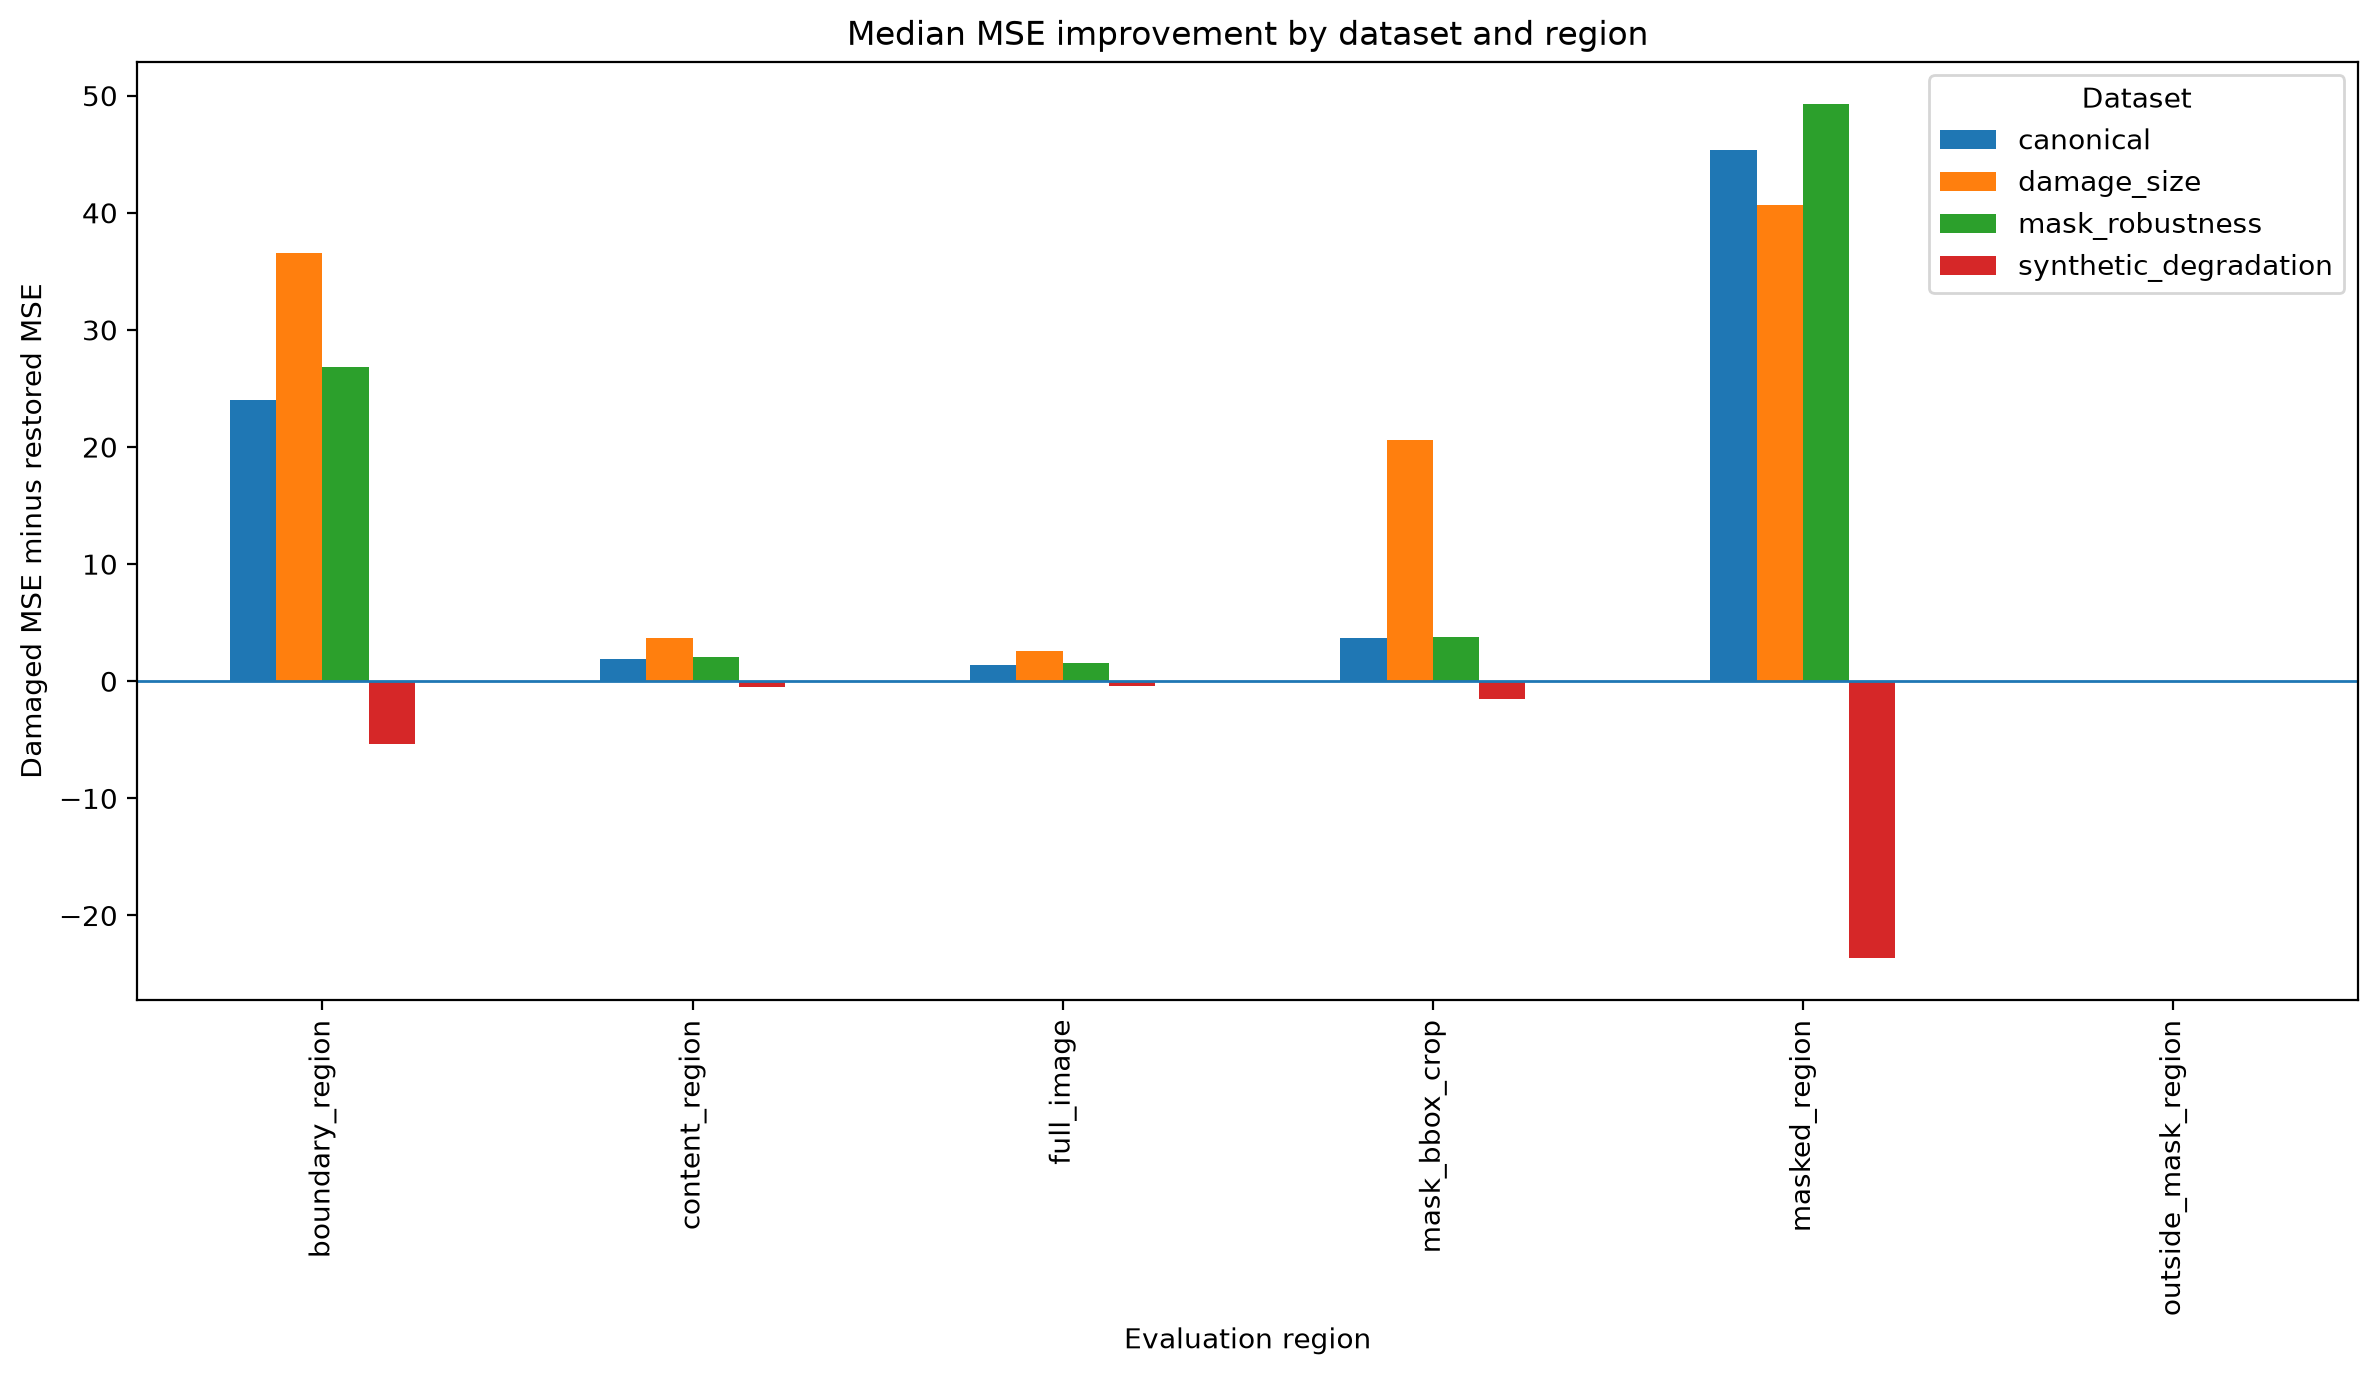

mask_area_vs_masked_mse_improvement


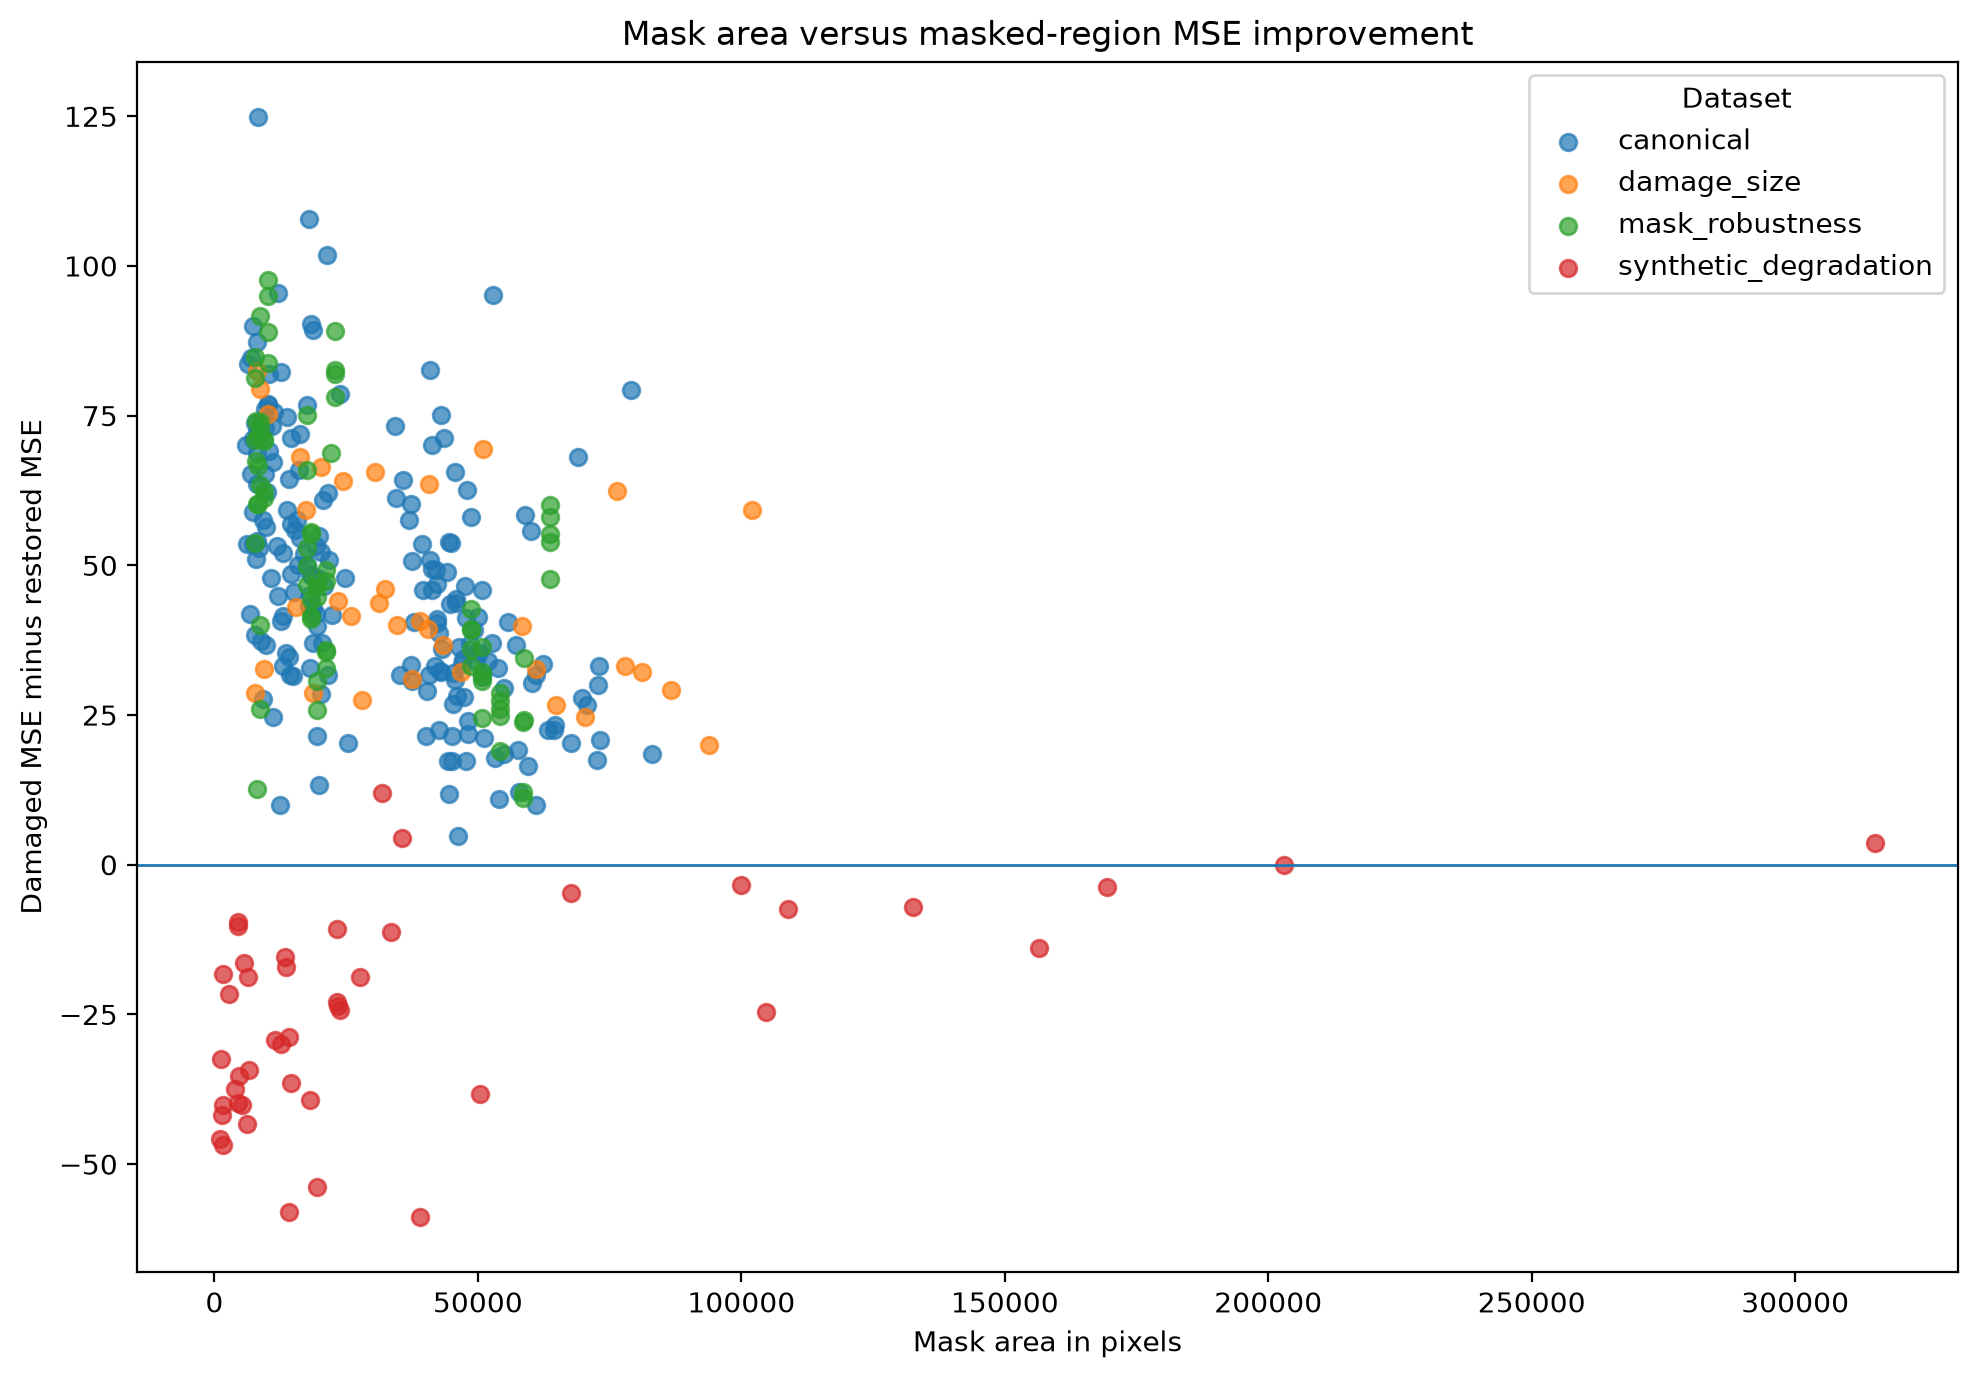

In [28]:
# Display the generated diagnostic figures inside the notebook

from IPython.display import (
    Image as IPythonImage,
    display as display_ipython,
)


for figure_row in (
    opencv_metric_figure_manifest_df
    .itertuples(
        index=False
    )
):
    figure_path = resolve_project_path(
        figure_row.figure_path
    )

    print(
        figure_row.figure_name
    )

    display_ipython(
        IPythonImage(
            filename=str(
                figure_path
            )
        )
    )

In [29]:
# Record the methodological interpretation policy and limitations

methodological_limitations = [
    {
        "topic": (
            "classical full-reference metrics"
        ),
        "limitation": (
            "MSE, MAE, PSNR, and SSIM quantify numerical "
            "similarity to the known clean reference. They do "
            "not directly measure historical plausibility, "
            "artistic appropriateness, semantic correctness, "
            "or conservation acceptability."
        ),
        "implication": (
            "The metrics must be interpreted alongside "
            "perceptual, semantic, texture, uncertainty, and "
            "visual analyses in later notebooks."
        ),
    },
    {
        "topic": (
            "masked-region evaluation"
        ),
        "limitation": (
            "Masked-region MSE, MAE, and PSNR treat all selected "
            "pixels equally and ignore spatial arrangement."
        ),
        "implication": (
            "Strong masked-region error reduction does not prove "
            "that reconstructed structures or brushwork are "
            "visually convincing."
        ),
    },
    {
        "topic": (
            "SSIM applicability"
        ),
        "limitation": (
            "SSIM requires contiguous spatial structure and is "
            "therefore not computed over irregular masked, "
            "boundary, or outside-mask pixel selections."
        ),
        "implication": (
            "SSIM comparisons are restricted to full-image, "
            "content-region, and mask-bounding-box crops."
        ),
    },
    {
        "topic": (
            "mask bounding-box crop"
        ),
        "limitation": (
            "The mask bounding-box crop includes unmasked context "
            "around the damaged region and may therefore dilute "
            "or stabilize the measured restoration effect."
        ),
        "implication": (
            "Bounding-box metrics should be interpreted together "
            "with masked-region and boundary-region metrics."
        ),
    },
    {
        "topic": (
            "boundary-region definition"
        ),
        "limitation": (
            "The boundary region is defined algorithmically using "
            f"a morphological band of "
            f"{BOUNDARY_WIDTH_PIXELS} pixels."
        ),
        "implication": (
            "Boundary scores depend partly on this chosen width "
            "and will later be complemented by dedicated seam and "
            "color-consistency analysis."
        ),
    },
    {
        "topic": (
            "outside-mask evaluation"
        ),
        "limitation": (
            "Outside-mask metrics are dominated by the large "
            "unchanged image area and may hide small unintended "
            "changes near the restoration boundary."
        ),
        "implication": (
            "Outside-mask metrics are diagnostic controls rather "
            "than primary restoration-quality measures."
        ),
    },
    {
        "topic": (
            "zero-control cases"
        ),
        "limitation": (
            "Zero-control cases contain no missing-content target "
            "and therefore do not support masked, bounding-box, "
            "or boundary-region evaluation."
        ),
        "implication": (
            "They are used to test whether the restoration pipeline "
            "unnecessarily alters intact images."
        ),
    },
    {
        "topic": (
            "synthetic degradation"
        ),
        "limitation": (
            "Synthetic-degradation masks represent grayscale "
            "effect intensity rather than ordinary binary "
            "missing-content masks. The evaluation target is "
            f"thresholded using intensity > "
            f"{MASK_BINARY_THRESHOLD}."
        ),
        "implication": (
            "Synthetic-degradation results remain supplementary "
            "and should not be pooled uncritically with primary "
            "missing-content experiments."
        ),
    },
    {
        "topic": (
            "model scope"
        ),
        "limitation": (
            "This notebook evaluates only OpenCV Telea outputs."
        ),
        "implication": (
            "Cross-model conclusions require equivalent metric "
            "computation for LaMa, Stable Diffusion, SDXL, and "
            "other restoration methods."
        ),
    },
]


methodological_limitations_df = pd.DataFrame(
    methodological_limitations
)


display(
    methodological_limitations_df
)

,topic,limitation,implication
0,classical full-reference metrics,"MSE, MAE, PSNR, and SSIM quantify numerical si...",The metrics must be interpreted alongside perc...
1,masked-region evaluation,"Masked-region MSE, MAE, and PSNR treat all sel...",Strong masked-region error reduction does not ...
2,SSIM applicability,SSIM requires contiguous spatial structure and...,"SSIM comparisons are restricted to full-image,..."
3,mask bounding-box crop,The mask bounding-box crop includes unmasked c...,Bounding-box metrics should be interpreted tog...
4,boundary-region definition,The boundary region is defined algorithmically...,Boundary scores depend partly on this chosen w...
5,outside-mask evaluation,Outside-mask metrics are dominated by the larg...,Outside-mask metrics are diagnostic controls r...
6,zero-control cases,Zero-control cases contain no missing-content ...,They are used to test whether the restoration ...
7,synthetic degradation,Synthetic-degradation masks represent grayscal...,Synthetic-degradation results remain supplemen...
8,model scope,This notebook evaluates only OpenCV Telea outp...,Cross-model conclusions require equivalent met...


In [30]:
# Consolidate validation checks into one audit table

audit_tables = [
    (
        "restoration_metadata_gate",
        restoration_metadata_checks_df,
    ),
    (
        "clean_metadata_gate",
        clean_metadata_checks_df,
    ),
    (
        "metric_input_gate",
        metric_input_checks_df,
    ),
    (
        "path_validation_gate",
        path_validation_checks_df,
    ),
    (
        "expected_manifest_gate",
        expected_metric_checks_df,
    ),
    (
        "smoke_test_gate",
        smoke_test_checks_df,
    ),
    (
        "full_metric_validation_gate",
        full_metric_validation_checks_df,
    ),
    (
        "save_reload_gate",
        save_reload_checks_df,
    ),
    (
        "runtime_summary_gate",
        runtime_summary_checks_df,
    ),
]


audit_rows = []


for audit_stage, audit_dataframe in (
    audit_tables
):
    for audit_row in (
        audit_dataframe
        .to_dict(
            orient="records"
        )
    ):
        audit_rows.append(
            {
                "notebook": (
                    NOTEBOOK_NAME
                ),
                "audit_stage": (
                    audit_stage
                ),
                "check": audit_row.get(
                    "check",
                    "",
                ),
                "observed": json.dumps(
                    audit_row.get(
                        "observed"
                    ),
                    default=str,
                    ensure_ascii=False,
                ),
                "expected": json.dumps(
                    audit_row.get(
                        "expected"
                    ),
                    default=str,
                    ensure_ascii=False,
                ),
                "passed": bool(
                    audit_row.get(
                        "passed",
                        False,
                    )
                ),
            }
        )


opencv_metric_audit_df = pd.DataFrame(
    audit_rows
)


opencv_metric_audit_df[
    "created_at_utc"
] = datetime.now(
    timezone.utc
).isoformat()


opencv_metric_audit_df.to_csv(
    AUDIT_OUTPUT_PATH,
    index=False,
)


if not AUDIT_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Metric audit CSV was not created."
    )


audit_reload_df = pd.read_csv(
    AUDIT_OUTPUT_PATH
)


audit_validation_df = pd.DataFrame(
    [
        {
            "check": (
                "audit_csv_exists"
            ),
            "observed": (
                AUDIT_OUTPUT_PATH.is_file()
            ),
            "expected": True,
            "passed": (
                AUDIT_OUTPUT_PATH.is_file()
            ),
        },
        {
            "check": (
                "audit_nonempty"
            ),
            "observed": len(
                audit_reload_df
            ),
            "expected": "> 0",
            "passed": (
                len(
                    audit_reload_df
                )
                > 0
            ),
        },
        {
            "check": (
                "all_audit_checks_passed"
            ),
            "observed": int(
                (
                    ~audit_reload_df[
                        "passed"
                    ]
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                audit_reload_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


display(
    opencv_metric_audit_df
)

display(
    audit_validation_df
)


if not (
    audit_validation_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric audit validation failed."
    )

,notebook,audit_stage,check,observed,expected,passed,created_at_utc
0,09_opencv_metrics_classical,restoration_metadata_gate,restoration_metadata_nonempty,410,"""> 0""",True,2026-07-25T22:41:30.116107+00:00
1,09_opencv_metrics_classical,restoration_metadata_gate,restoration_case_ids_unique,0,0,True,2026-07-25T22:41:30.116107+00:00
2,09_opencv_metrics_classical,restoration_metadata_gate,all_restoration_statuses_ok,0,0,True,2026-07-25T22:41:30.116107+00:00
3,09_opencv_metrics_classical,restoration_metadata_gate,required_datasets_present,"[""canonical"", ""damage_size"", ""mask_robustness""...","[""canonical"", ""damage_size""]",True,2026-07-25T22:41:30.116107+00:00
4,09_opencv_metrics_classical,restoration_metadata_gate,no_unsupported_datasets,[],[],True,2026-07-25T22:41:30.116107+00:00
5,09_opencv_metrics_classical,restoration_metadata_gate,model_name_consistent,"[""opencv_telea""]","[""opencv_telea""]",True,2026-07-25T22:41:30.116107+00:00
6,09_opencv_metrics_classical,clean_metadata_gate,clean_metadata_nonempty,50,"""> 0""",True,2026-07-25T22:41:30.116107+00:00
7,09_opencv_metrics_classical,clean_metadata_gate,painting_ids_unique,0,0,True,2026-07-25T22:41:30.116107+00:00
8,09_opencv_metrics_classical,clean_metadata_gate,content_coordinates_valid,0,0,True,2026-07-25T22:41:30.116107+00:00
9,09_opencv_metrics_classical,metric_input_gate,metric_input_row_count,410,410,True,2026-07-25T22:41:30.116107+00:00


,check,observed,expected,passed
0,audit_csv_exists,True,True,True
1,audit_nonempty,48,> 0,True
2,all_audit_checks_passed,0,0,True


In [31]:
# Create a machine-readable reproducibility manifest

def dataframe_records_for_json(
    dataframe: pd.DataFrame,
) -> list[dict[str, Any]]:
    """Convert a DataFrame into JSON-safe records."""
    json_ready_dataframe = (
        dataframe
        .replace(
            {
                np.nan: None,
                np.inf: "Infinity",
                -np.inf: "-Infinity",
            }
        )
    )

    return json.loads(
        json_ready_dataframe.to_json(
            orient="records"
        )
    )


manifest_created_at_utc = datetime.now(
    timezone.utc
).isoformat()


opencv_metric_manifest = {
    "notebook": NOTEBOOK_NAME,
    "created_at_utc": (
        manifest_created_at_utc
    ),
    "project_root": (
        PROJECT_ROOT.as_posix()
    ),
    "model_name": (
        MODEL_NAME
    ),
    "metric_schema_version": (
        METRIC_SCHEMA_VERSION
    ),
    "metric_implementation": (
        METRIC_IMPLEMENTATION_NAME
    ),
    "inputs": {
        "restoration_metadata": {
            "path": project_relative_path(
                RESTORATION_METADATA_PATH
            ),
            "sha256": file_sha256(
                RESTORATION_METADATA_PATH
            ),
            "rows": len(
                restoration_metadata_df
            ),
        },
        "clean_metadata": {
            "path": project_relative_path(
                CLEAN_METADATA_PATH
            ),
            "sha256": file_sha256(
                CLEAN_METADATA_PATH
            ),
            "rows": len(
                clean_metadata_df
            ),
        },
    },
    "datasets": {
        "required": list(
            REQUIRED_DATASETS
        ),
        "optional": list(
            OPTIONAL_DATASETS
        ),
        "included": (
            included_dataset_names
        ),
        "summary": (
            dataframe_records_for_json(
                restoration_dataset_summary_df
            )
        ),
    },
    "metric_policy": {
        "metrics": [
            "MSE",
            "MAE",
            "PSNR",
            "SSIM",
        ],
        "evaluation_regions": list(
            ALL_EVALUATION_REGIONS
        ),
        "ssim_supported_regions": list(
            SSIM_SUPPORTED_REGIONS
        ),
        "pixel_only_regions": list(
            PIXEL_ONLY_REGIONS
        ),
        "mask_binary_threshold_rule": (
            f"mask intensity > "
            f"{MASK_BINARY_THRESHOLD}"
        ),
        "mask_bbox_margin": (
            MASK_BBOX_MARGIN
        ),
        "boundary_width_pixels": (
            BOUNDARY_WIDTH_PIXELS
        ),
        "zero_control_regions": [
            "full_image",
            "content_region",
            "outside_mask_region",
        ],
        "synthetic_degradation_policy": (
            "supplementary"
        ),
    },
    "execution": {
        "input_cases": len(
            metric_input_df
        ),
        "expected_metric_rows": (
            expected_total_metric_rows
        ),
        "generated_metric_rows": len(
            opencv_classical_metrics_df
        ),
        "failed_cases": len(
            opencv_classical_metric_failures_df
        ),
        "smoke_test_cases": len(
            smoke_test_input_df
        ),
        "smoke_test_runtime_seconds": (
            smoke_test_runtime_seconds
        ),
        "full_metric_runtime_seconds": (
            full_metric_runtime_seconds
        ),
        "runtime_summary": (
            dataframe_records_for_json(
                opencv_metric_runtime_summary_df
            )
        ),
    },
    "outputs": {
        "metrics": {
            "path": project_relative_path(
                METRICS_OUTPUT_PATH
            ),
            "sha256": file_sha256(
                METRICS_OUTPUT_PATH
            ),
            "rows": len(
                opencv_classical_metrics_df
            ),
        },
        "audit": {
            "path": project_relative_path(
                AUDIT_OUTPUT_PATH
            ),
            "sha256": file_sha256(
                AUDIT_OUTPUT_PATH
            ),
            "rows": len(
                opencv_metric_audit_df
            ),
        },
        "figures": (
            dataframe_records_for_json(
                opencv_metric_figure_manifest_df
            )
        ),
        "report": {
            "path": project_relative_path(
                REPORT_OUTPUT_PATH
            ),
        },
    },
    "summaries": {
        "dataset_region_summary": (
            dataframe_records_for_json(
                opencv_metric_summary_df
            )
        ),
        "improvement_rates": (
            dataframe_records_for_json(
                opencv_metric_improvement_rate_df
            )
        ),
        "best_masked_cases": (
            dataframe_records_for_json(
                opencv_best_masked_cases_df
            )
        ),
        "worst_masked_cases": (
            dataframe_records_for_json(
                opencv_worst_masked_cases_df
            )
        ),
    },
    "limitations": (
        methodological_limitations
    ),
    "runtime_environment": (
        dataframe_records_for_json(
            runtime_environment_df
        )
    ),
}


with MANIFEST_OUTPUT_PATH.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        opencv_metric_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


if not MANIFEST_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Metric manifest JSON was not created."
    )


with MANIFEST_OUTPUT_PATH.open(
    "r",
    encoding="utf-8",
) as manifest_file:
    reloaded_metric_manifest = json.load(
        manifest_file
    )


manifest_validation_df = pd.DataFrame(
    [
        {
            "check": (
                "manifest_json_exists"
            ),
            "observed": (
                MANIFEST_OUTPUT_PATH.is_file()
            ),
            "expected": True,
            "passed": (
                MANIFEST_OUTPUT_PATH.is_file()
            ),
        },
        {
            "check": (
                "manifest_notebook_matches"
            ),
            "observed": (
                reloaded_metric_manifest.get(
                    "notebook"
                )
            ),
            "expected": (
                NOTEBOOK_NAME
            ),
            "passed": (
                reloaded_metric_manifest.get(
                    "notebook"
                )
                == NOTEBOOK_NAME
            ),
        },
        {
            "check": (
                "manifest_metric_rows_match"
            ),
            "observed": (
                reloaded_metric_manifest[
                    "execution"
                ][
                    "generated_metric_rows"
                ]
            ),
            "expected": len(
                opencv_classical_metrics_df
            ),
            "passed": (
                reloaded_metric_manifest[
                    "execution"
                ][
                    "generated_metric_rows"
                ]
                == len(
                    opencv_classical_metrics_df
                )
            ),
        },
        {
            "check": (
                "manifest_metric_checksum_matches"
            ),
            "observed": (
                reloaded_metric_manifest[
                    "outputs"
                ][
                    "metrics"
                ][
                    "sha256"
                ]
            ),
            "expected": file_sha256(
                METRICS_OUTPUT_PATH
            ),
            "passed": (
                reloaded_metric_manifest[
                    "outputs"
                ][
                    "metrics"
                ][
                    "sha256"
                ]
                == file_sha256(
                    METRICS_OUTPUT_PATH
                )
            ),
        },
    ]
)


print(
    "Saved manifest:",
    MANIFEST_OUTPUT_PATH,
)


display(
    manifest_validation_df
)


if not (
    manifest_validation_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric manifest validation failed."
    )

Saved manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\opencv_metrics_classical_manifest.json


E:\HFCache\tmp\ipykernel_27412\3141797317.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(


,check,observed,expected,passed
0,manifest_json_exists,True,True,True
1,manifest_notebook_matches,09_opencv_metrics_classical,09_opencv_metrics_classical,True
2,manifest_metric_rows_match,2295,2295,True
3,manifest_metric_checksum_matches,1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca10...,1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca10...,True


In [32]:
# Create a machine-readable reproducibility manifest

def dataframe_records_for_json(
    dataframe: pd.DataFrame,
) -> list[dict[str, Any]]:
    """Convert a DataFrame into JSON-safe records."""
    json_ready_dataframe = (
        dataframe
        .replace(
            {
                np.nan: None,
                np.inf: "Infinity",
                -np.inf: "-Infinity",
            }
        )
    )

    return json.loads(
        json_ready_dataframe.to_json(
            orient="records"
        )
    )


manifest_created_at_utc = datetime.now(
    timezone.utc
).isoformat()


opencv_metric_manifest = {
    "notebook": NOTEBOOK_NAME,
    "created_at_utc": (
        manifest_created_at_utc
    ),
    "project_root": (
        PROJECT_ROOT.as_posix()
    ),
    "model_name": (
        MODEL_NAME
    ),
    "metric_schema_version": (
        METRIC_SCHEMA_VERSION
    ),
    "metric_implementation": (
        METRIC_IMPLEMENTATION_NAME
    ),
    "inputs": {
        "restoration_metadata": {
            "path": project_relative_path(
                RESTORATION_METADATA_PATH
            ),
            "sha256": file_sha256(
                RESTORATION_METADATA_PATH
            ),
            "rows": len(
                restoration_metadata_df
            ),
        },
        "clean_metadata": {
            "path": project_relative_path(
                CLEAN_METADATA_PATH
            ),
            "sha256": file_sha256(
                CLEAN_METADATA_PATH
            ),
            "rows": len(
                clean_metadata_df
            ),
        },
    },
    "datasets": {
        "required": list(
            REQUIRED_DATASETS
        ),
        "optional": list(
            OPTIONAL_DATASETS
        ),
        "included": (
            included_dataset_names
        ),
        "summary": (
            dataframe_records_for_json(
                restoration_dataset_summary_df
            )
        ),
    },
    "metric_policy": {
        "metrics": [
            "MSE",
            "MAE",
            "PSNR",
            "SSIM",
        ],
        "evaluation_regions": list(
            ALL_EVALUATION_REGIONS
        ),
        "ssim_supported_regions": list(
            SSIM_SUPPORTED_REGIONS
        ),
        "pixel_only_regions": list(
            PIXEL_ONLY_REGIONS
        ),
        "mask_binary_threshold_rule": (
            f"mask intensity > "
            f"{MASK_BINARY_THRESHOLD}"
        ),
        "mask_bbox_margin": (
            MASK_BBOX_MARGIN
        ),
        "boundary_width_pixels": (
            BOUNDARY_WIDTH_PIXELS
        ),
        "zero_control_regions": [
            "full_image",
            "content_region",
            "outside_mask_region",
        ],
        "synthetic_degradation_policy": (
            "supplementary"
        ),
    },
    "execution": {
        "input_cases": len(
            metric_input_df
        ),
        "expected_metric_rows": (
            expected_total_metric_rows
        ),
        "generated_metric_rows": len(
            opencv_classical_metrics_df
        ),
        "failed_cases": len(
            opencv_classical_metric_failures_df
        ),
        "smoke_test_cases": len(
            smoke_test_input_df
        ),
        "smoke_test_runtime_seconds": (
            smoke_test_runtime_seconds
        ),
        "full_metric_runtime_seconds": (
            full_metric_runtime_seconds
        ),
        "runtime_summary": (
            dataframe_records_for_json(
                opencv_metric_runtime_summary_df
            )
        ),
    },
    "outputs": {
        "metrics": {
            "path": project_relative_path(
                METRICS_OUTPUT_PATH
            ),
            "sha256": file_sha256(
                METRICS_OUTPUT_PATH
            ),
            "rows": len(
                opencv_classical_metrics_df
            ),
        },
        "audit": {
            "path": project_relative_path(
                AUDIT_OUTPUT_PATH
            ),
            "sha256": file_sha256(
                AUDIT_OUTPUT_PATH
            ),
            "rows": len(
                opencv_metric_audit_df
            ),
        },
        "figures": (
            dataframe_records_for_json(
                opencv_metric_figure_manifest_df
            )
        ),
        "report": {
            "path": project_relative_path(
                REPORT_OUTPUT_PATH
            ),
        },
    },
    "summaries": {
        "dataset_region_summary": (
            dataframe_records_for_json(
                opencv_metric_summary_df
            )
        ),
        "improvement_rates": (
            dataframe_records_for_json(
                opencv_metric_improvement_rate_df
            )
        ),
        "best_masked_cases": (
            dataframe_records_for_json(
                opencv_best_masked_cases_df
            )
        ),
        "worst_masked_cases": (
            dataframe_records_for_json(
                opencv_worst_masked_cases_df
            )
        ),
    },
    "limitations": (
        methodological_limitations
    ),
    "runtime_environment": (
        dataframe_records_for_json(
            runtime_environment_df
        )
    ),
}


with MANIFEST_OUTPUT_PATH.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        opencv_metric_manifest,
        manifest_file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


if not MANIFEST_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Metric manifest JSON was not created."
    )


with MANIFEST_OUTPUT_PATH.open(
    "r",
    encoding="utf-8",
) as manifest_file:
    reloaded_metric_manifest = json.load(
        manifest_file
    )


manifest_validation_df = pd.DataFrame(
    [
        {
            "check": (
                "manifest_json_exists"
            ),
            "observed": (
                MANIFEST_OUTPUT_PATH.is_file()
            ),
            "expected": True,
            "passed": (
                MANIFEST_OUTPUT_PATH.is_file()
            ),
        },
        {
            "check": (
                "manifest_notebook_matches"
            ),
            "observed": (
                reloaded_metric_manifest.get(
                    "notebook"
                )
            ),
            "expected": (
                NOTEBOOK_NAME
            ),
            "passed": (
                reloaded_metric_manifest.get(
                    "notebook"
                )
                == NOTEBOOK_NAME
            ),
        },
        {
            "check": (
                "manifest_metric_rows_match"
            ),
            "observed": (
                reloaded_metric_manifest[
                    "execution"
                ][
                    "generated_metric_rows"
                ]
            ),
            "expected": len(
                opencv_classical_metrics_df
            ),
            "passed": (
                reloaded_metric_manifest[
                    "execution"
                ][
                    "generated_metric_rows"
                ]
                == len(
                    opencv_classical_metrics_df
                )
            ),
        },
        {
            "check": (
                "manifest_metric_checksum_matches"
            ),
            "observed": (
                reloaded_metric_manifest[
                    "outputs"
                ][
                    "metrics"
                ][
                    "sha256"
                ]
            ),
            "expected": file_sha256(
                METRICS_OUTPUT_PATH
            ),
            "passed": (
                reloaded_metric_manifest[
                    "outputs"
                ][
                    "metrics"
                ][
                    "sha256"
                ]
                == file_sha256(
                    METRICS_OUTPUT_PATH
                )
            ),
        },
    ]
)


print(
    "Saved manifest:",
    MANIFEST_OUTPUT_PATH,
)


display(
    manifest_validation_df
)


if not (
    manifest_validation_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric manifest validation failed."
    )

Saved manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\opencv_metrics_classical_manifest.json


E:\HFCache\tmp\ipykernel_27412\3141797317.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(


,check,observed,expected,passed
0,manifest_json_exists,True,True,True
1,manifest_notebook_matches,09_opencv_metrics_classical,09_opencv_metrics_classical,True
2,manifest_metric_rows_match,2295,2295,True
3,manifest_metric_checksum_matches,1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca10...,1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca10...,True


In [33]:
# Create a concise human-readable notebook report

primary_masked_rows_df = (
    masked_metric_rows_df.loc[
        masked_metric_rows_df[
            "metric_applicability"
        ]
        .astype(str)
        .eq(
            "primary"
        )
    ]
    .copy()
)


primary_masked_case_count = len(
    primary_masked_rows_df
)


primary_masked_mse_improvement_rate = (
    float(
        primary_masked_rows_df[
            "mse_improvement"
        ]
        .gt(0)
        .mean()
    )
    if primary_masked_case_count
    else np.nan
)


primary_masked_mae_improvement_rate = (
    float(
        primary_masked_rows_df[
            "mae_improvement"
        ]
        .gt(0)
        .mean()
    )
    if primary_masked_case_count
    else np.nan
)


primary_masked_psnr_improvement_rate = (
    float(
        primary_masked_rows_df[
            "psnr_improvement"
        ]
        .gt(0)
        .mean()
    )
    if primary_masked_case_count
    else np.nan
)


def format_rate(
    value: float,
) -> str:
    """Format a proportion as a percentage."""
    if pd.isna(
        value
    ):
        return "not applicable"

    return f"{value * 100:.2f}%"


report_lines = [
    "# OpenCV Telea Classical Metric Report",
    "",
    f"- Generated: `{manifest_created_at_utc}`",
    f"- Notebook: `{NOTEBOOK_NAME}`",
    f"- Model: `{MODEL_NAME}`",
    f"- Metric schema version: `{METRIC_SCHEMA_VERSION}`",
    "",
    "## Scope",
    "",
    (
        "This report summarizes full-reference classical metrics "
        "for the OpenCV Telea restoration outputs generated by "
        "Notebook 08."
    ),
    "",
    "## Input inventory",
    "",
    f"- Restoration cases: **{len(metric_input_df)}**",
    (
        "- Included datasets: **"
        + ", ".join(
            included_dataset_names
        )
        + "**"
    ),
    (
        f"- Zero-control cases: **"
        f"{int(metric_input_df['is_zero_control'].sum())}**"
    ),
    (
        f"- Nonzero-mask cases: **"
        f"{int((~metric_input_df['is_zero_control'].astype(bool)).sum())}**"
    ),
    "",
    "## Metric inventory",
    "",
    (
        f"- Metric rows: **"
        f"{len(opencv_classical_metrics_df)}**"
    ),
    (
        "- Regions: **"
        + ", ".join(
            ALL_EVALUATION_REGIONS
        )
        + "**"
    ),
    (
        "- SSIM regions: **"
        + ", ".join(
            SSIM_SUPPORTED_REGIONS
        )
        + "**"
    ),
    (
        f"- Mask threshold: **intensity > "
        f"{MASK_BINARY_THRESHOLD}**"
    ),
    (
        f"- Boundary width: **"
        f"{BOUNDARY_WIDTH_PIXELS} pixels**"
    ),
    "",
    "## Primary masked-region findings",
    "",
    (
        f"- Primary masked cases: **"
        f"{primary_masked_case_count}**"
    ),
    (
        "- Positive MSE improvement rate: **"
        f"{format_rate(primary_masked_mse_improvement_rate)}**"
    ),
    (
        "- Positive MAE improvement rate: **"
        f"{format_rate(primary_masked_mae_improvement_rate)}**"
    ),
    (
        "- Positive PSNR improvement rate: **"
        f"{format_rate(primary_masked_psnr_improvement_rate)}**"
    ),
    "",
    "Positive values indicate that restoration moved the output "
    "closer to the clean reference under the corresponding metric.",
    "",
    "## Dataset and region summary",
    "",
    opencv_metric_summary_df.to_markdown(
        index=False
    ),
    "",
    "## Improvement rates",
    "",
    opencv_metric_improvement_rate_df.to_markdown(
        index=False
    ),
    "",
    "## Best masked-region cases",
    "",
    opencv_best_masked_cases_df.to_markdown(
        index=False
    ),
    "",
    "## Weakest masked-region cases",
    "",
    opencv_worst_masked_cases_df.to_markdown(
        index=False
    ),
    "",
    "## Generated figures",
    "",
    opencv_metric_figure_manifest_df[
        [
            "figure_name",
            "figure_path",
            "figure_type",
        ]
    ].to_markdown(
        index=False
    ),
    "",
    "## Methodological limitations",
    "",
]


for limitation_record in (
    methodological_limitations
):
    report_lines.extend(
        [
            (
                f"### "
                f"{limitation_record['topic']}"
            ),
            "",
            limitation_record[
                "limitation"
            ],
            "",
            (
                "**Implication:** "
                + limitation_record[
                    "implication"
                ]
            ),
            "",
        ]
    )


report_lines.extend(
    [
        "## Canonical outputs",
        "",
        (
            f"- Metrics: "
            f"`{project_relative_path(METRICS_OUTPUT_PATH)}`"
        ),
        (
            f"- Audit: "
            f"`{project_relative_path(AUDIT_OUTPUT_PATH)}`"
        ),
        (
            f"- Manifest: "
            f"`{project_relative_path(MANIFEST_OUTPUT_PATH)}`"
        ),
        (
            f"- Figure directory: "
            f"`{project_relative_path(FIGURE_DIR)}`"
        ),
        "",
        "## Interpretation policy",
        "",
        (
            "Synthetic-degradation results are supplementary. "
            "Classical metric improvements do not by themselves "
            "establish historical plausibility, semantic correctness, "
            "style consistency, or conservation suitability."
        ),
    ]
)


REPORT_OUTPUT_PATH.write_text(
    "\n".join(
        report_lines
    ),
    encoding="utf-8",
)


if not REPORT_OUTPUT_PATH.is_file():
    raise RuntimeError(
        "Metric Markdown report was not created."
    )


report_text = REPORT_OUTPUT_PATH.read_text(
    encoding="utf-8"
)


report_validation_df = pd.DataFrame(
    [
        {
            "check": (
                "report_exists"
            ),
            "observed": (
                REPORT_OUTPUT_PATH.is_file()
            ),
            "expected": True,
            "passed": (
                REPORT_OUTPUT_PATH.is_file()
            ),
        },
        {
            "check": (
                "report_nonempty"
            ),
            "observed": len(
                report_text
            ),
            "expected": "> 0",
            "passed": (
                len(
                    report_text
                )
                > 0
            ),
        },
        {
            "check": (
                "report_contains_metric_section"
            ),
            "observed": (
                "## Metric inventory"
                in report_text
            ),
            "expected": True,
            "passed": (
                "## Metric inventory"
                in report_text
            ),
        },
        {
            "check": (
                "report_contains_limitations"
            ),
            "observed": (
                "## Methodological limitations"
                in report_text
            ),
            "expected": True,
            "passed": (
                "## Methodological limitations"
                in report_text
            ),
        },
    ]
)


print(
    "Saved report:",
    REPORT_OUTPUT_PATH,
)


display(
    report_validation_df
)


if not (
    report_validation_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Metric report validation failed."
    )

Saved report: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\opencv_metrics_classical_report.md


,check,observed,expected,passed
0,report_exists,True,True,True
1,report_nonempty,33141,> 0,True
2,report_contains_metric_section,True,True,True
3,report_contains_limitations,True,True,True


In [34]:
# Final canonical output gate

canonical_output_records = [
    {
        "artifact_name": (
            "classical_metrics"
        ),
        "artifact_type": (
            "csv"
        ),
        "artifact_path": (
            METRICS_OUTPUT_PATH
        ),
        "expected_nonempty": True,
    },
    {
        "artifact_name": (
            "classical_metric_audit"
        ),
        "artifact_type": (
            "csv"
        ),
        "artifact_path": (
            AUDIT_OUTPUT_PATH
        ),
        "expected_nonempty": True,
    },
    {
        "artifact_name": (
            "classical_metric_manifest"
        ),
        "artifact_type": (
            "json"
        ),
        "artifact_path": (
            MANIFEST_OUTPUT_PATH
        ),
        "expected_nonempty": True,
    },
    {
        "artifact_name": (
            "classical_metric_report"
        ),
        "artifact_type": (
            "markdown"
        ),
        "artifact_path": (
            REPORT_OUTPUT_PATH
        ),
        "expected_nonempty": True,
    },
]


for figure_row in (
    opencv_metric_figure_manifest_df
    .itertuples(
        index=False
    )
):
    canonical_output_records.append(
        {
            "artifact_name": (
                figure_row.figure_name
            ),
            "artifact_type": (
                "figure"
            ),
            "artifact_path": (
                resolve_project_path(
                    figure_row.figure_path
                )
            ),
            "expected_nonempty": True,
        }
    )


canonical_output_validation_rows = []


for artifact_record in (
    canonical_output_records
):
    artifact_path = Path(
        artifact_record[
            "artifact_path"
        ]
    )

    artifact_exists = (
        artifact_path.is_file()
    )

    artifact_size_bytes = (
        artifact_path.stat().st_size
        if artifact_exists
        else 0
    )

    artifact_nonempty = (
        artifact_size_bytes
        > 0
    )

    canonical_output_validation_rows.append(
        {
            "artifact_name": (
                artifact_record[
                    "artifact_name"
                ]
            ),
            "artifact_type": (
                artifact_record[
                    "artifact_type"
                ]
            ),
            "artifact_path": (
                project_relative_path(
                    artifact_path
                )
            ),
            "exists": (
                artifact_exists
            ),
            "size_bytes": (
                artifact_size_bytes
            ),
            "sha256": (
                file_sha256(
                    artifact_path
                )
                if artifact_exists
                else ""
            ),
            "passed": (
                artifact_exists
                and
                (
                    artifact_nonempty
                    if artifact_record[
                        "expected_nonempty"
                    ]
                    else True
                )
            ),
        }
    )


canonical_output_validation_df = pd.DataFrame(
    canonical_output_validation_rows
)


final_semantic_checks_df = pd.DataFrame(
    [
        {
            "check": (
                "all_canonical_artifacts_valid"
            ),
            "observed": int(
                (
                    ~canonical_output_validation_df[
                        "passed"
                    ]
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                canonical_output_validation_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "canonical_metric_rows_match_expected"
            ),
            "observed": len(
                reloaded_opencv_classical_metrics_df
            ),
            "expected": (
                expected_total_metric_rows
            ),
            "passed": (
                len(
                    reloaded_opencv_classical_metrics_df
                )
                == expected_total_metric_rows
            ),
        },
        {
            "check": (
                "canonical_metric_ids_match_expected"
            ),
            "observed": len(
                set(
                    reloaded_opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
                ^ expected_metric_row_ids
            ),
            "expected": 0,
            "passed": (
                set(
                    reloaded_opencv_classical_metrics_df[
                        "metric_row_id"
                    ]
                    .astype(str)
                )
                == expected_metric_row_ids
            ),
        },
        {
            "check": (
                "canonical_audit_passed"
            ),
            "observed": int(
                (
                    ~audit_reload_df[
                        "passed"
                    ]
                    .astype(bool)
                ).sum()
            ),
            "expected": 0,
            "passed": bool(
                audit_reload_df[
                    "passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": (
                "no_full_computation_failures"
            ),
            "observed": len(
                opencv_classical_metric_failures_df
            ),
            "expected": 0,
            "passed": (
                opencv_classical_metric_failures_df.empty
            ),
        },
    ]
)


display(
    canonical_output_validation_df
)

display(
    final_semantic_checks_df
)


if not (
    canonical_output_validation_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Final canonical artifact gate failed."
    )


if not (
    final_semantic_checks_df[
        "passed"
    ]
    .astype(bool)
    .all()
):
    raise RuntimeError(
        "Final classical metric semantic gate failed."
    )


print(
    "Final canonical output gate passed."
)

,artifact_name,artifact_type,artifact_path,exists,size_bytes,sha256,passed
0,classical_metrics,csv,data/processed/metrics/metrics_opencv_telea_cl...,True,1690289,1b8d018cfdb7254c5b65ee1f371015f4cf7da67f50ca10...,True
1,classical_metric_audit,csv,outputs/09_opencv_metrics_classical/opencv_met...,True,6148,c8b562cd21a6f161e482e11f1db717c52ec411e1145324...,True
2,classical_metric_manifest,json,outputs/reports/opencv_metrics_classical_manif...,True,53051,fe6dcffca3158b1de59dce48034e24fab940292327100a...,True
3,classical_metric_report,markdown,outputs/reports/opencv_metrics_classical_repor...,True,33344,1767af3af6e4fd5d70213ae5e4341bfb5da0006f36ea6b...,True
4,median_mse_improvement_by_region,figure,outputs/figures/opencv_metrics_classical/media...,True,110423,9487f3b4569c465f86b479aff37f909168cc1ab74fd9c8...,True
5,mask_area_vs_masked_mse_improvement,figure,outputs/figures/opencv_metrics_classical/mask_...,True,242423,12009717c7c040a87f2d2b8b4db6f7715fdff57b793663...,True


,check,observed,expected,passed
0,all_canonical_artifacts_valid,0,0,True
1,canonical_metric_rows_match_expected,2295,2295,True
2,canonical_metric_ids_match_expected,0,0,True
3,canonical_audit_passed,0,0,True
4,no_full_computation_failures,0,0,True


Final canonical output gate passed.


In [35]:
# Notebook completion summary

notebook_completion_summary_df = pd.DataFrame(
    [
        {
            "item": (
                "notebook"
            ),
            "value": (
                NOTEBOOK_NAME
            ),
        },
        {
            "item": (
                "model"
            ),
            "value": (
                MODEL_NAME
            ),
        },
        {
            "item": (
                "input_cases"
            ),
            "value": len(
                metric_input_df
            ),
        },
        {
            "item": (
                "datasets"
            ),
            "value": (
                ", ".join(
                    included_dataset_names
                )
            ),
        },
        {
            "item": (
                "metric_rows"
            ),
            "value": len(
                opencv_classical_metrics_df
            ),
        },
        {
            "item": (
                "evaluation_regions"
            ),
            "value": (
                ", ".join(
                    ALL_EVALUATION_REGIONS
                )
            ),
        },
        {
            "item": (
                "failed_cases"
            ),
            "value": len(
                opencv_classical_metric_failures_df
            ),
        },
        {
            "item": (
                "runtime_seconds"
            ),
            "value": round(
                full_metric_runtime_seconds,
                3,
            ),
        },
        {
            "item": (
                "canonical_metric_path"
            ),
            "value": (
                project_relative_path(
                    METRICS_OUTPUT_PATH
                )
            ),
        },
        {
            "item": (
                "audit_path"
            ),
            "value": (
                project_relative_path(
                    AUDIT_OUTPUT_PATH
                )
            ),
        },
        {
            "item": (
                "manifest_path"
            ),
            "value": (
                project_relative_path(
                    MANIFEST_OUTPUT_PATH
                )
            ),
        },
        {
            "item": (
                "report_path"
            ),
            "value": (
                project_relative_path(
                    REPORT_OUTPUT_PATH
                )
            ),
        },
        {
            "item": (
                "figures_generated"
            ),
            "value": len(
                opencv_metric_figure_manifest_df
            ),
        },
        {
            "item": (
                "final_status"
            ),
            "value": (
                "complete"
            ),
        },
    ]
)


display(
    notebook_completion_summary_df
)


print(
    "Notebook 09 completed successfully."
)

print(
    "Canonical classical metrics:",
    METRICS_OUTPUT_PATH,
)

print(
    "Audit:",
    AUDIT_OUTPUT_PATH,
)

print(
    "Manifest:",
    MANIFEST_OUTPUT_PATH,
)

print(
    "Report:",
    REPORT_OUTPUT_PATH,
)

,item,value
0,notebook,09_opencv_metrics_classical
1,model,opencv_telea
2,input_cases,410
3,datasets,"canonical, damage_size, mask_robustness, synth..."
4,metric_rows,2295
5,evaluation_regions,"full_image, content_region, masked_region, mas..."
6,failed_cases,0
7,runtime_seconds,865.332
8,canonical_metric_path,data/processed/metrics/metrics_opencv_telea_cl...
9,audit_path,outputs/09_opencv_metrics_classical/opencv_met...


Notebook 09 completed successfully.
Canonical classical metrics: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metrics\metrics_opencv_telea_classical.csv
Audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\09_opencv_metrics_classical\opencv_metrics_classical_audit.csv
Manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\opencv_metrics_classical_manifest.json
Report: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\opencv_metrics_classical_report.md


# Notebook 09 Summary: OpenCV Telea Classical Metric Evaluation

## Objective

This notebook computes standardized full-reference classical image quality metrics for the OpenCV Telea restoration outputs produced in Notebook 08. The objective is to establish a reproducible numerical baseline for evaluating restoration quality prior to introducing perceptual, semantic, texture, uncertainty, and cross-model analyses.

---

## Inputs

### Required inputs

- `metadata_restored_opencv_telea.csv`
- `metadata_processed_clean.csv`

### Restoration model

- OpenCV Telea

### Included datasets

- Primary missing-content restoration cases
- Supplementary synthetic-degradation cases
- Zero-control (no-damage) validation cases

---

## Evaluation Metrics

The notebook computes the following full-reference metrics:

- Mean Squared Error (MSE)
- Mean Absolute Error (MAE)
- Peak Signal-to-Noise Ratio (PSNR)
- Structural Similarity Index (SSIM)

---

## Evaluation Regions

Metrics are computed over six standardized evaluation regions:

1. Full image
2. Content region
3. Outside-mask region
4. Masked region
5. Mask bounding-box crop
6. Boundary region

SSIM is evaluated only on spatially contiguous regions:

- Full image
- Content region
- Mask bounding-box crop

---

## Validation Workflow

The notebook validates:

- input metadata
- preprocessing metadata
- file paths
- expected metric manifest
- smoke-test execution
- complete metric execution
- dataset-region coverage
- canonical output schema
- saved CSV integrity
- audit generation
- reproducibility manifest
- Markdown report
- final artifact integrity

Only after every validation gate passes are the outputs considered canonical.

---

## Generated Outputs

### Metrics

- `metrics_opencv_telea_classical.csv`

### Audit

- Classical metric audit CSV

### Manifest

- Reproducibility JSON manifest

### Report

- Human-readable Markdown report

### Figures

- Median MSE improvement by evaluation region
- Mask area versus masked-region MSE improvement

---

## Methodological Notes

This notebook measures numerical similarity to the known clean reference.

These metrics **do not directly evaluate**

- historical plausibility
- artistic realism
- semantic correctness
- stylistic consistency
- conservation suitability

Those aspects are evaluated in later notebooks using perceptual, texture, uncertainty, semantic, and cross-model analyses.

Synthetic-degradation experiments remain supplementary and are not interpreted together with the primary missing-content restoration experiments.

---

## Role Within the Thesis Pipeline

Notebook 09 establishes the classical evaluation baseline for OpenCV Telea restorations.

Subsequent notebooks reuse the same standardized evaluation methodology for additional restoration models, enabling direct, fair, and reproducible cross-model comparisons throughout the remainder of the thesis.